# Acoustic Feature Extraction

This notebook converts the validated Xeno-canto recordings into quantitative acoustic representations for exploratory analysis, dimensionality reduction, clustering, and subsequent machine-learning experiments.

The feature-extraction pipeline is designed to preserve ecological and signal-processing information while maintaining reproducibility. Original recordings remain unchanged, and all transformations are applied to analysis copies.

The primary acoustic analysis uses a 1–10 kHz frequency band to emphasize the frequency range most relevant to avian vocalizations in the study dataset. A full-spectrum comparison will also be retained where appropriate so that the effect of band-limiting can be evaluated rather than assumed.

To improve comparability across recordings of different durations, recordings of at least 10 seconds will be analyzed using complete 10-second windows. Recordings shorter than 10 seconds will be analyzed using their full available duration rather than being padded or repeated. Short recordings will be explicitly flagged so that window duration can be evaluated as a potential source of variation in downstream analyses.

The notebook will calculate acoustic indices, entropy measures, conventional spectral features, and MFCC-based representations. Window-level measurements will be preserved before aggregation to the recording level. Extraction parameters, software versions, processing outcomes, and errors will be documented to maintain a reproducible feature-extraction pipeline.

## Feature Extraction Strategy

The feature pipeline is organized into several levels:

### Level 1 — Ecoacoustic indices
- Acoustic Complexity Index (ACI)
- Acoustic Diversity Index (ADI)
- Normalized Difference Soundscape Index (NDSI)
- Bioacoustic Index (BI)

### Level 2 — Information-theoretic features
- Spectral entropy
- Temporal entropy

### Level 3 — Signal-level features
- Duration
- RMS energy
- Peak amplitude
- Zero-crossing rate

### Level 4 — Spectral features
- Spectral centroid
- Spectral bandwidth
- Spectral rolloff
- Spectral contrast

### Level 5 — Cepstral features
- MFCCs

Later research stages may add learned representations such as BirdNET or Perch embeddings.

The primary ecological indices will be calculated using a 1–10 kHz frequency band. Full-spectrum measurements will be retained as a comparison where feasible, allowing later analysis of whether conclusions are sensitive to the chosen frequency range.

In [2]:
from pathlib import Path
import json
import sys
import platform
import importlib.metadata as importlib_metadata

import numpy as np
import pandas as pd
import librosa
import soundfile as sf

print("Imports successful.")

Imports successful.


In [138]:
# Project root
# Project root
def find_project_root(marker="README.md"):
    p = Path.cwd().resolve()

    while not (p / marker).exists():
        if p.parent == p:
            raise RuntimeError(f"Could not find {marker} above {Path.cwd()}")
        p = p.parent

    return p


PROJECT_ROOT = find_project_root()

# Input data
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MASTER_METADATA_PATH = PROCESSED_DIR / "master_metadata.csv"

AUDIO_DIR = PROJECT_ROOT / "audio" / "validated"

# Output directories
FIGURES_DIR = PROJECT_ROOT / "figures"
EDA_FIGURES_DIR = FIGURES_DIR / "eda"
SPECTROGRAM_DIR = FIGURES_DIR / "spectrograms"

MANIFEST_DIR = PROJECT_ROOT / "data" / "manifests"

# Create required directories
SPECTROGRAM_DIR.mkdir(parents=True, exist_ok=True)
MANIFEST_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Master metadata:", MASTER_METADATA_PATH)
print("Audio directory:", AUDIO_DIR)
print("Spectrogram directory:", SPECTROGRAM_DIR)

Project root: C:\Users\Samanwita\Downloads\from-soundscapes-to-biodiversity
Master metadata: C:\Users\Samanwita\Downloads\from-soundscapes-to-biodiversity\data\processed\master_metadata.csv
Audio directory: C:\Users\Samanwita\Downloads\from-soundscapes-to-biodiversity\audio\validated
Spectrogram directory: C:\Users\Samanwita\Downloads\from-soundscapes-to-biodiversity\figures\spectrograms


In [4]:
master_metadata = pd.read_csv(MASTER_METADATA_PATH)

print("Shape:", master_metadata.shape)
print("\nColumns:")
print(master_metadata.columns.tolist())

Shape: (275, 41)

Columns:
['state', 'recording_id', 'common_name', 'scientific_name', 'date', 'time', 'latitude', 'longitude', 'duration_metadata', 'audio_url', 'source_url', 'license', 'audit_action', 'audit_reason', 'flag_short_duration', 'flag_low_amplitude', 'flag_clipping', 'flag_low_quality', 'flag_any', 'file_size_bytes', 'duration_seconds', 'rms', 'peak_amplitude', 'quality', 'date_original', 'time_original', 'datetime_local', 'source_timezone', 'has_date', 'has_time', 'has_datetime_local', 'year', 'month', 'day_of_year', 'hour', 'minute', 'season', 'duration_metadata_seconds', 'duration_difference_seconds', 'duration_category', 'species_id']


In [5]:
master_metadata.head()

,state,recording_id,common_name,scientific_name,date,time,latitude,longitude,duration_metadata,audio_url,...,year,month,day_of_year,hour,minute,season,duration_metadata_seconds,duration_difference_seconds,duration_category,species_id
0,CA,375492,African Collared Dove,Streptopelia roseogrisea,2017-06-14,15:00:00,33.9220,-117.2617,0:05,https://xeno-canto.org/375492/download,...,2017.0,6.0,165.0,15.0,0.0,Summer,5,0.251678,Short (3–10s),Streptopelia roseogrisea
1,CA,952203,Allen's Hummingbird,Selasphorus sasin,2024-11-24,08:00:00,33.6104,-117.7392,0:38,https://xeno-canto.org/952203/download,...,2024.0,11.0,329.0,8.0,0.0,Fall,38,0.632562,Long (≥30s),Selasphorus sasin
2,CA,452094,American Coot,Fulica americana,2018-01-30,12:56:00,33.2016,-115.5970,0:18,https://xeno-canto.org/452094/download,...,2018.0,1.0,30.0,12.0,56.0,Winter,18,0.960000,Medium (10–30s),Fulica americana
3,CA,172887,American Wigeon,Mareca americana,2012-03-23,09:54:00,32.5640,-117.1256,0:11,https://xeno-canto.org/172887/download,...,2012.0,3.0,83.0,9.0,54.0,Spring,11,0.424000,Medium (10–30s),Mareca americana
4,CA,449497,Anna's Hummingbird,Calypte anna,2018-10-21,07:46:00,32.6860,-117.2430,1:50,https://xeno-canto.org/449497/download,...,2018.0,10.0,294.0,7.0,46.0,Fall,110,0.208000,Long (≥30s),Calypte anna


In [6]:
print("Recordings:", len(master_metadata))
print("Unique recording IDs:", master_metadata["recording_id"].nunique())
print("Unique species:", master_metadata["species_id"].nunique())

print("\nBy state:")
print(master_metadata["state"].value_counts())

print("\nFlagged recordings:")
print(master_metadata["flag_any"].value_counts())

Recordings: 275
Unique recording IDs: 275
Unique species: 159

By state:
state
CA    100
TX    100
AZ     75
Name: count, dtype: int64

Flagged recordings:
flag_any
False    208
True      67
Name: count, dtype: int64


In [7]:
audio_inventory = []

for _, row in master_metadata.iterrows():
    recording_id = str(row["recording_id"])
    state = str(row["state"])

    audio_path = AUDIO_DIR / f"{state}_{recording_id}.mp3"

    try:
        info = sf.info(audio_path)

        audio_inventory.append({
            "recording_id": recording_id,
            "state": state,
            "audio_path": str(audio_path),
            "sample_rate": info.samplerate,
            "frames": info.frames,
            "channels": info.channels,
            "duration_seconds_sf": info.duration,
            "subtype": info.subtype,
            "format": info.format,
            "file_size_bytes": audio_path.stat().st_size,
            "status": "OK",
            "error": pd.NA,
        })

    except Exception as e:
        audio_inventory.append({
            "recording_id": recording_id,
            "state": state,
            "audio_path": str(audio_path),
            "sample_rate": pd.NA,
            "frames": pd.NA,
            "channels": pd.NA,
            "duration_seconds_sf": pd.NA,
            "subtype": pd.NA,
            "format": pd.NA,
            "file_size_bytes": (
                audio_path.stat().st_size
                if audio_path.exists()
                else pd.NA
            ),
            "status": "ERROR",
            "error": str(e),
        })

audio_inventory = pd.DataFrame(audio_inventory)

print("Inventory shape:", audio_inventory.shape)
print("\nStatus:")
print(audio_inventory["status"].value_counts())

Inventory shape: (275, 12)

Status:
status
OK    275
Name: count, dtype: int64


In [8]:
print("Sample-rate distribution:")
print(
    audio_inventory["sample_rate"]
    .value_counts(dropna=False)
    .sort_index()
)

Sample-rate distribution:
sample_rate
16000      1
22050      4
32000      6
44100    110
48000    153
96000      1
Name: count, dtype: int64


In [9]:
print("Channel distribution:")
print(
    audio_inventory["channels"]
    .value_counts(dropna=False)
    .sort_index()
)

print("\nAudio format distribution:")
print(audio_inventory["format"].value_counts(dropna=False))

print("\nSubtype distribution:")
print(audio_inventory["subtype"].value_counts(dropna=False))

Channel distribution:
channels
1    203
2     72
Name: count, dtype: int64

Audio format distribution:
format
MP3    261
WAV     14
Name: count, dtype: int64

Subtype distribution:
subtype
MPEG_LAYER_III    261
PCM_24              8
PCM_16              5
PCM_32              1
Name: count, dtype: int64


## Audio Standardization Configuration

The validated recordings contain heterogeneous sampling rates, channel configurations, and audio formats. To ensure that downstream acoustic features are comparable, each recording will be converted to a standardized analysis representation while the original recording remains unchanged.

The analysis representation will use a sampling rate of 22,050 Hz and mono audio. A 22,050 Hz sampling rate provides a Nyquist frequency of 11,025 Hz, which supports the primary 1–10 kHz analysis band for recordings originally sampled at or above 22,050 Hz.

One recording was originally sampled at 16 kHz and therefore contains no information above its original 8 kHz Nyquist frequency. Resampling cannot recover this missing information. This recording will therefore be retained but explicitly flagged as incompatible with the complete 1–10 kHz analysis band.

The primary acoustic-index analysis will use the 1–10 kHz band. A full-spectrum representation will be retained for sensitivity analyses where appropriate.

Recordings of at least 10 seconds will be divided into complete 10-second analysis windows. Recordings shorter than 10 seconds will be analyzed using their entire available duration without zero-padding or looping. Window duration and short-window status will be retained as explicit metadata.

In [21]:
FEATURE_CONFIG = {
    "analysis_sample_rate": 22050,
    "target_channels": 1,

    "resampling_method": "soxr_hq",

    "primary_frequency_min_hz": 1000,
    "primary_frequency_max_hz": 10000,

    "ndsi_biophony_min_hz": 1000,
    "ndsi_biophony_max_hz": 10000,
    "ndsi_anthrophony_min_hz": 0,
    "ndsi_anthrophony_max_hz": 1000,

    "window_seconds": 10.0,
    "window_overlap": 0.0,

    "short_recording_policy": "use_entire_recording",
    "padding": False,
    "looping": False,

    "random_seed": 42,
}

## Reproducibility and Software Versions

Feature extraction depends on the numerical and signal-processing implementations provided by the software environment. The Python version, operating system, and relevant package versions are therefore recorded alongside the feature-extraction configuration.

Recording these versions makes the resulting feature tables reproducible and provides a provenance record for later research comparisons.

In [22]:
# Record software and environment versions

PACKAGE_NAMES = [
    "numpy",
    "pandas",
    "scipy",
    "librosa",
    "soundfile",
    "soxr",
    "scikit-maad",
    "scikit-learn"
]
VERSION_INFO = {
    "python": platform.python_version(),
    "platform": platform.platform(),
}

for package in PACKAGE_NAMES:
    try:
        VERSION_INFO[package] = importlib_metadata.version(package)
    except importlib_metadata.PackageNotFoundError:
        VERSION_INFO[package] = "NOT INSTALLED"

print(json.dumps(VERSION_INFO, indent=4))

{
    "python": "3.11.9",
    "platform": "Windows-10-10.0.26200-SP0",
    "numpy": "2.4.6",
    "pandas": "2.2.2",
    "scipy": "1.17.1",
    "librosa": "0.10.2",
    "soundfile": "0.14.0",
    "soxr": "1.1.0",
    "scikit-maad": "1.5.1",
    "scikit-learn": "1.9.1"
}


In [12]:
# Combine configuration and software provenance

EXTRACTION_PROVENANCE = {
    "feature_config": FEATURE_CONFIG,
    "software_versions": VERSION_INFO,
}

print(json.dumps(EXTRACTION_PROVENANCE, indent=4))

{
    "feature_config": {
        "analysis_sample_rate": 22050,
        "target_channels": 1,
        "primary_frequency_min_hz": 1000,
        "primary_frequency_max_hz": 10000,
        "ndsi_biophony_min_hz": 1000,
        "ndsi_biophony_max_hz": 10000,
        "ndsi_anthrophony_min_hz": 0,
        "ndsi_anthrophony_max_hz": 1000,
        "window_seconds": 10.0,
        "window_overlap": 0.0,
        "short_recording_policy": "use_entire_recording",
        "padding": false,
        "looping": false,
        "random_seed": 42
    },
    "software_versions": {
        "python": "3.11.9",
        "platform": "Windows-10-10.0.26200-SP0",
        "numpy": "2.4.6",
        "pandas": "2.2.2",
        "scipy": "1.17.1",
        "librosa": "0.10.2",
        "soundfile": "0.14.0",
        "scikit-maad": "1.5.1",
        "scikit-learn": "1.9.1"
    }
}


## Inspect the Acoustic-Index Library

The ecoacoustic indices in this project will be computed using scikit-maad. Because feature implementations and function signatures can vary across library versions, the installed scikit-maad environment is inspected before the extraction pipeline is implemented.

The inspection focuses on the acoustic-index functions, soundscape indices, and preprocessing utilities required for the primary 1–10 kHz analysis.

In [13]:
import maad
import maad.features
import maad.sound

print("scikit-maad version:", maad.__version__)

print("\nmaad.features functions:")
print([
    name for name in dir(maad.features)
    if not name.startswith("_")
])

scikit-maad version: 1.5.1

maad.features functions:
['acoustic_complexity_index', 'acoustic_diversity_index', 'acoustic_eveness_index', 'acoustic_gradient_index', 'acoustic_richness_index', 'all_shape_features', 'all_spectral_alpha_indices', 'all_spectral_features', 'all_temporal_alpha_indices', 'all_temporal_features', 'alpha_indices', 'bioacoustics_index', 'centroid_features', 'composite_soundscape_descriptors', 'filter_bank_2d_nodc', 'filter_multires', 'frequency_entropy', 'frequency_raoq', 'graphical_soundscape', 'more_entropy', 'number_of_peaks', 'opt_shape_presets', 'peak_frequency', 'plot_graph', 'region_of_interest_index', 'region_of_interest_index_deprecated', 'roughness', 'shape', 'shape_features', 'shape_features_raw', 'soundscape_index', 'spectral', 'spectral_activity', 'spectral_bandwidth', 'spectral_cover', 'spectral_entropy', 'spectral_events', 'spectral_leq', 'spectral_moments', 'spectral_quantile', 'surface_roughness', 'temporal', 'temporal_activity', 'temporal_durati

In [14]:
print("maad.sound functions:")
print([
    name for name in dir(maad.sound)
    if not name.startswith("_")
])

maad.sound functions:
['avg_amplitude_spectro', 'avg_power_spectro', 'envelope', 'filter', 'fir_filter', 'gain', 'input_output', 'linear_to_octave', 'load', 'load_spectrogram', 'load_url', 'median_equalizer', 'metrics', 'normalize', 'pcen', 'remove_background', 'remove_background_along_axis', 'remove_background_morpho', 'resample', 'select_bandwidth', 'sharpness', 'sinc', 'smooth', 'spectral_snr', 'spectral_subtraction', 'spectro_func', 'spectrogram', 'spectrum', 'temporal_snr', 'transform', 'trim', 'trim_func', 'wave2frames', 'write']


In [15]:
# Inspect specifically relevant functions

candidate_feature_names = [
    "acoustic_complexity_index",
    "acoustic_diversity_index",
    "normalized_difference_soundscape_index",
    "bioacoustics_index",
    "spectral_entropy",
    "temporal_entropy",
]

for name in candidate_feature_names:
    print(f"{name}: {getattr(maad.features, name, None)}")

acoustic_complexity_index: <function acoustic_complexity_index at 0x000001C147DCD1C0>
acoustic_diversity_index: <function acoustic_diversity_index at 0x000001C147DCD260>
normalized_difference_soundscape_index: None
bioacoustics_index: <function bioacoustics_index at 0x000001C147DCD440>
spectral_entropy: <function spectral_entropy at 0x000001C147DCCF40>
temporal_entropy: <function temporal_entropy at 0x000001C147DCCB80>


In [16]:
# Inspect available documentation/signatures for relevant functions

import inspect

for name in candidate_feature_names:
    func = getattr(maad.features, name, None)

    if func is not None:
        print(f"\n{'=' * 70}")
        print(name)
        print(inspect.signature(func))
        print(inspect.getdoc(func)[:1200])


acoustic_complexity_index
(Sxx)
Compute the Acoustic Complexity Index (ACI) from a spectrogram [1]_.
    
Parameters
----------
Sxx : ndarray of floats
    2d : Spectrogram (i.e matrix of spectrum)

Returns
-------    
ACI_xx: 2d ndarray of scalars
    Acoustic Complexity Index of the spectrogram

ACI_per_bin: 1d ndarray of scalars
    ACI value for each frequency bin
    sum(ACI_xx,axis=1)
    
ACI_sum: scalar
    Sum of ACI value per frequency bin (Common definition)
    sum(ACI_per_bin)

Notes
-----   
ACI depends on the duration of the spectrogram as the derivation of the signal
is normalized by the sum of the signal. 
Thus, if the background noise is high due to high acoustic activity the
normalization by the sum of the signal reduced ACI.
So ACI is low when there is no acoustic activity or high acoustic activity 
with continuous background noise.
ACI is high only when acoustic activity is medium, with sounds well above
the background noise.
    
References
----------
.. [1] Pier

In [17]:
import inspect

CORE_FUNCTIONS = [
    "acoustic_complexity_index",
    "acoustic_diversity_index",
    "bioacoustics_index",
    "spectral_entropy",
    "temporal_entropy",
    "soundscape_index",
    "frequency_entropy",
    "zero_crossing_rate",
    "spectral_bandwidth",
]

for name in CORE_FUNCTIONS:
    func = getattr(maad.features, name, None)

    print("\n" + "=" * 80)
    print(name)

    if func is None:
        print("NOT AVAILABLE")
    else:
        print("Signature:")
        print(inspect.signature(func))


acoustic_complexity_index
Signature:
(Sxx)

acoustic_diversity_index
Signature:
(Sxx, fn, fmin=0, fmax=20000, bin_step=1000, dB_threshold=-50, index='shannon')

bioacoustics_index
Signature:
(Sxx, fn, flim=(2000, 15000), R_compatible='soundecology')

spectral_entropy
Signature:
(Sxx, fn, flim=None, display=False)

temporal_entropy
Signature:
(s, compatibility='QUT', mode='fast', Nt=512)

soundscape_index
Signature:
(Sxx_power, fn, flim_bioPh=(1000, 10000), flim_antroPh=(0, 1000), R_compatible='soundecology')

frequency_entropy
Signature:
(X, compatibility='QUT')

zero_crossing_rate
Signature:
(s, fs, roi=None)

spectral_bandwidth
Signature:
(s, fs, nperseg=1024, roi=None, as_pandas=False, **kwargs)


In [18]:
# Inspect the sound-processing functions we may use
# for band-limiting and spectrogram generation.

SOUND_FUNCTIONS = [
    "load",
    "resample",
    "filter",
    "fir_filter",
    "spectrogram",
    "select_bandwidth",
]

for name in SOUND_FUNCTIONS:
    func = getattr(maad.sound, name, None)

    print("\n" + "=" * 80)
    print(name)

    if func is None:
        print("NOT AVAILABLE")
    else:
        print("Signature:")
        print(inspect.signature(func))


load
Signature:
(filename, channel='left', detrend=True, verbose=False, display=False, savefig=None, **kwargs)

resample
Signature:
(s, fs, target_fs, res_type='scipy_poly', **kwargs)

filter
Signature:


TypeError: <module 'maad.sound.filter' from 'c:\\Users\\Samanwita\\Downloads\\from-soundscapes-to-biodiversity\\venv\\Lib\\site-packages\\maad\\sound\\filter.py'> is not a callable object

In [ ]:
import inspect

print("soundscape_index signature:")
print(inspect.signature(maad.features.soundscape_index))

print("\nDocumentation:")
print(inspect.getdoc(maad.features.soundscape_index))

soundscape_index signature:
(Sxx_power, fn, flim_bioPh=(1000, 10000), flim_antroPh=(0, 1000), R_compatible='soundecology')

Documentation:
Compute the Normalized Difference Soundscape Index from a power spectrogram [1]_.
    
Parameters
----------
Sxx_power : ndarray of floats
    2d : Power Spectrogram

fn : vector
    frequency vector 
    
flim_bioPh : tupple (fmin, fmax), optional, default is (1000,10000)
    Frequency band of the biophony

flim_antroPh: tupple (fmin, fmax), optional, default is (0,1000)
    Frequency band of the anthropophony

R_compatible : string, optional, default is "soundecology"
    if 'soundecology', the result is similar to the package SoundEcology in R 
    Otherwise, the result is specific to maad or Seewave R package
    
Returns
-------
NDSI : scalar
    (bioPh-antroPh)/(bioPh+antroPh)
ratioBA : scalar
    biophonic energy / anthropophonic energy
antroPh : scalar
    Acoustic energy in the anthropophonic bandwidth
bioPh : scalar
    Acoustic energy in 

In [ ]:
print("Available soundscape-index-related functions:")

for name in [
    "soundscape_index",
    "bioacoustics_index",
    "acoustic_diversity_index",
    "acoustic_complexity_index",
]:
    func = getattr(maad.features, name)
    print(f"\n{name}")
    print(inspect.signature(func))

Available soundscape-index-related functions:

soundscape_index
(Sxx_power, fn, flim_bioPh=(1000, 10000), flim_antroPh=(0, 1000), R_compatible='soundecology')

bioacoustics_index
(Sxx, fn, flim=(2000, 15000), R_compatible='soundecology')

acoustic_diversity_index
(Sxx, fn, fmin=0, fmax=20000, bin_step=1000, dB_threshold=-50, index='shannon')

acoustic_complexity_index
(Sxx)


## Standardized Audio Loading

Each validated recording is loaded without modifying the original file. Stereo recordings are converted to mono by averaging their channels, and recordings are resampled to the standardized analysis rate of 22,050 Hz.

The original sampling rate and channel count are retained as provenance variables. Resampling changes the numerical representation of the signal but does not recover frequency information that was absent from the original recording. In particular, the recording originally sampled at 16 kHz cannot provide information above its original 8 kHz Nyquist frequency and will therefore be flagged for the primary 1–10 kHz analysis.

The standardized waveform is returned as a one-dimensional floating-point array suitable for subsequent windowing and acoustic feature extraction.

In [20]:
def load_standardized_audio(audio_path, target_sr=22050):
    """
    Load an audio recording and standardize it for acoustic analysis.

    Standardization:
    - Preserve original sample rate and channel count for provenance.
    - Convert stereo/multichannel audio to mono by averaging channels.
    - Resample to the target sample rate using SoXR high-quality resampling.
    - Return float32 audio.
    """

    y, original_sr = librosa.load(
        audio_path,
        sr=None,
        mono=False
    )

    # Determine original channel count and convert to mono
    if y.ndim == 1:
        original_channels = 1
        y_mono = y
    else:
        original_channels = y.shape[0]
        y_mono = np.mean(y, axis=0)

    # Resample only when necessary
    if original_sr != target_sr:
        y_standardized = librosa.resample(
            y_mono,
            orig_sr=original_sr,
            target_sr=target_sr,
            res_type="soxr_hq"
        )
    else:
        y_standardized = y_mono

    return (
        np.asarray(y_standardized, dtype=np.float32),
        int(original_sr),
        int(original_channels)
    )

In [ ]:
# Select representative recordings:
# 1. a long recording
# 2. a medium recording
# 3. a very short recording

test_rows = pd.concat([
    master_metadata.loc[
        master_metadata["duration_seconds"].idxmax()
    ].to_frame().T,

    master_metadata.loc[
        (
            master_metadata["duration_seconds"] - 20
        ).abs().idxmin()
    ].to_frame().T,

    master_metadata.loc[
        master_metadata["duration_seconds"].idxmin()
    ].to_frame().T,
]).drop_duplicates(subset=["recording_id"])

test_rows[
    [
        "recording_id",
        "state",
        "common_name",
        "duration_seconds",
        "flag_any",
        "flag_short_duration"
    ]
]

,recording_id,state,common_name,duration_seconds,flag_any,flag_short_duration
161,611001,AZ,Greater Roadrunner,646.992,False,False
81,1152009,CA,Calliope Hummingbird,20.076979,True,False
7,691650,CA,Black-chinned Hummingbird,0.696,True,True


In [ ]:
import sys
!{sys.executable} -m pip install resampy


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import resampy

print("resampy version:", resampy.__version__)

resampy version: 0.4.3


In [ ]:
import sys
import resampy
import librosa

print("Python executable:")
print(sys.executable)

print("\nPython version:")
print(sys.version)

print("\nresampy version:")
print(resampy.__version__)

print("\nresampy location:")
print(resampy.__file__)

print("\nlibrosa version:")
print(librosa.__version__)

print("\nlibrosa location:")
print(librosa.__file__)

Python executable:
c:\Users\Samanwita\Downloads\from-soundscapes-to-biodiversity\venv\Scripts\python.exe

Python version:
3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]

resampy version:
0.4.3

resampy location:
c:\Users\Samanwita\Downloads\from-soundscapes-to-biodiversity\venv\Lib\site-packages\resampy\__init__.py

librosa version:
0.10.2

librosa location:
c:\Users\Samanwita\Downloads\from-soundscapes-to-biodiversity\venv\Lib\site-packages\librosa\__init__.py


In [19]:
import soxr
import librosa
import numpy as np

print("soxr version:", soxr.__version__)

# Small test signal
test_signal = np.random.randn(22050).astype(np.float32)

resampled = librosa.resample(
    test_signal,
    orig_sr=22050,
    target_sr=16000,
    res_type="soxr_hq"
)

print("Original samples:", len(test_signal))
print("Resampled samples:", len(resampled))
print("Resampling test: SUCCESS")

soxr version: 1.1.0
Original samples: 22050
Resampled samples: 16000
Resampling test: SUCCESS


In [24]:
test_rows = pd.concat([
    master_metadata.loc[master_metadata["duration_seconds"].idxmax()].to_frame().T,
    master_metadata.loc[
        (master_metadata["duration_seconds"] - 20).abs().idxmin()
    ].to_frame().T,
    master_metadata.loc[
        master_metadata["duration_seconds"].idxmin()
    ].to_frame().T,
]).drop_duplicates(subset=["recording_id"])

print(
    test_rows[
        ["recording_id", "state", "scientific_name", "duration_seconds"]
    ].to_string(index=False)
)

recording_id state         scientific_name duration_seconds
      611001    AZ Geococcyx californianus          646.992
     1152009    CA    Selasphorus calliope        20.076979
      691650    CA   Archilochus alexandri            0.696


In [25]:
for _, row in test_rows.iterrows():

    recording_id = str(row["recording_id"])
    state = str(row["state"])

    audio_path = AUDIO_DIR / f"{state}_{recording_id}.mp3"

    y, original_sr, original_channels = load_standardized_audio(
        audio_path,
        target_sr=FEATURE_CONFIG["analysis_sample_rate"]
    )

    standardized_duration = (
        len(y) / FEATURE_CONFIG["analysis_sample_rate"]
    )

    print(
        f"Recording: {recording_id} | "
        f"Species: {row['scientific_name']} | "
        f"Original SR: {original_sr:,} Hz | "
        f"Original channels: {original_channels} | "
        f"Standardized SR: "
        f"{FEATURE_CONFIG['analysis_sample_rate']:,} Hz | "
        f"Standardized channels: 1 | "
        f"Samples: {len(y):,} | "
        f"Duration: {standardized_duration:.2f} sec"
    )

Recording: 611001 | Species: Geococcyx californianus | Original SR: 48,000 Hz | Original channels: 1 | Standardized SR: 22,050 Hz | Standardized channels: 1 | Samples: 14,266,174 | Duration: 646.99 sec
Recording: 1152009 | Species: Selasphorus calliope | Original SR: 48,000 Hz | Original channels: 1 | Standardized SR: 22,050 Hz | Standardized channels: 1 | Samples: 442,698 | Duration: 20.08 sec
Recording: 691650 | Species: Archilochus alexandri | Original SR: 48,000 Hz | Original channels: 1 | Standardized SR: 22,050 Hz | Standardized channels: 1 | Samples: 15,347 | Duration: 0.70 sec


In [26]:
def create_analysis_windows(
    y,
    sample_rate=22050,
    window_seconds=10.0
):
    """
    Split standardized audio into analysis windows.

    Policy:
    - Recordings shorter than the target window:
        use the entire recording once.
    - Recordings >= target window:
        use complete non-overlapping windows only.
    - No padding.
    - No looping.
    - Any incomplete final window is excluded.
    """

    window_samples = int(window_seconds * sample_rate)
    n_samples = len(y)

    # Short recording: use the entire available signal
    if n_samples < window_samples:
        return [{
            "window_index": 0,
            "start_sample": 0,
            "end_sample": n_samples,
            "window_start_seconds": 0.0,
            "window_end_seconds": n_samples / sample_rate,
            "window_duration_used": n_samples / sample_rate,
            "flag_short_window": True,
        }]

    # Standard recordings: complete windows only
    n_windows = n_samples // window_samples

    windows = []

    for i in range(n_windows):
        start_sample = i * window_samples
        end_sample = start_sample + window_samples

        windows.append({
            "window_index": i,
            "start_sample": start_sample,
            "end_sample": end_sample,
            "window_start_seconds": start_sample / sample_rate,
            "window_end_seconds": end_sample / sample_rate,
            "window_duration_used": window_seconds,
            "flag_short_window": False,
        })

    return windows

In [27]:
for _, row in test_rows.iterrows():

    recording_id = str(row["recording_id"])
    state = str(row["state"])

    audio_path = AUDIO_DIR / f"{state}_{recording_id}.mp3"

    y, original_sr, original_channels = load_standardized_audio(
        audio_path,
        target_sr=FEATURE_CONFIG["analysis_sample_rate"]
    )

    windows = create_analysis_windows(
        y,
        sample_rate=FEATURE_CONFIG["analysis_sample_rate"],
        window_seconds=FEATURE_CONFIG["window_seconds"]
    )

    print(f"\nRecording: {recording_id}")
    print(f"Original duration: {len(y) / 22050:.2f} sec")
    print(f"Number of analysis windows: {len(windows)}")

    for window in windows[:5]:
        print(window)


Recording: 611001
Original duration: 646.99 sec
Number of analysis windows: 64
{'window_index': 0, 'start_sample': 0, 'end_sample': 220500, 'window_start_seconds': 0.0, 'window_end_seconds': 10.0, 'window_duration_used': 10.0, 'flag_short_window': False}
{'window_index': 1, 'start_sample': 220500, 'end_sample': 441000, 'window_start_seconds': 10.0, 'window_end_seconds': 20.0, 'window_duration_used': 10.0, 'flag_short_window': False}
{'window_index': 2, 'start_sample': 441000, 'end_sample': 661500, 'window_start_seconds': 20.0, 'window_end_seconds': 30.0, 'window_duration_used': 10.0, 'flag_short_window': False}
{'window_index': 3, 'start_sample': 661500, 'end_sample': 882000, 'window_start_seconds': 30.0, 'window_end_seconds': 40.0, 'window_duration_used': 10.0, 'flag_short_window': False}
{'window_index': 4, 'start_sample': 882000, 'end_sample': 1102500, 'window_start_seconds': 40.0, 'window_end_seconds': 50.0, 'window_duration_used': 10.0, 'flag_short_window': False}

Recording: 115

In [28]:
SPECTROGRAM_CONFIG = {
    "n_fft": 2048,
    "hop_length": 512,
    "window": "hann",
    "center": False,
    "power": 2.0,
}

print("Spectrogram configuration:")
for key, value in SPECTROGRAM_CONFIG.items():
    print(f"{key}: {value}")

Spectrogram configuration:
n_fft: 2048
hop_length: 512
window: hann
center: False
power: 2.0


In [29]:
# Select the representative recording
row = master_metadata.loc[
    master_metadata["recording_id"].astype(str) == "1152009"
].iloc[0]

recording_id = str(row["recording_id"])
state = str(row["state"])

audio_path = AUDIO_DIR / f"{state}_{recording_id}.mp3"

# Load and standardize
y, original_sr, original_channels = load_standardized_audio(
    audio_path,
    target_sr=FEATURE_CONFIG["analysis_sample_rate"]
)

# Create analysis windows
windows = create_analysis_windows(
    y,
    sample_rate=FEATURE_CONFIG["analysis_sample_rate"],
    window_seconds=FEATURE_CONFIG["window_seconds"]
)

# Extract the first 10-second window
window = windows[0]

y_window = y[
    window["start_sample"]:window["end_sample"]
]

print("Recording:", recording_id)
print("Window duration:", len(y_window) / FEATURE_CONFIG["analysis_sample_rate"])
print("Samples:", len(y_window))

Recording: 1152009
Window duration: 10.0
Samples: 220500


In [30]:
sr = FEATURE_CONFIG["analysis_sample_rate"]

S = librosa.stft(
    y_window,
    n_fft=SPECTROGRAM_CONFIG["n_fft"],
    hop_length=SPECTROGRAM_CONFIG["hop_length"],
    window=SPECTROGRAM_CONFIG["window"],
    center=SPECTROGRAM_CONFIG["center"]
)

S_power = np.abs(S) ** SPECTROGRAM_CONFIG["power"]

frequencies = librosa.fft_frequencies(
    sr=sr,
    n_fft=SPECTROGRAM_CONFIG["n_fft"]
)

times = librosa.frames_to_time(
    np.arange(S_power.shape[1]),
    sr=sr,
    hop_length=SPECTROGRAM_CONFIG["hop_length"],
    n_fft=SPECTROGRAM_CONFIG["n_fft"]
)

print("Spectrogram shape:", S_power.shape)
print("Frequency range:", frequencies.min(), "to", frequencies.max(), "Hz")
print("Time range:", times.min(), "to", times.max(), "sec")

Spectrogram shape: (1025, 427)
Frequency range: 0.0 to 11025.0 Hz
Time range: 0.046439909297052155 to 9.93814058956916 sec


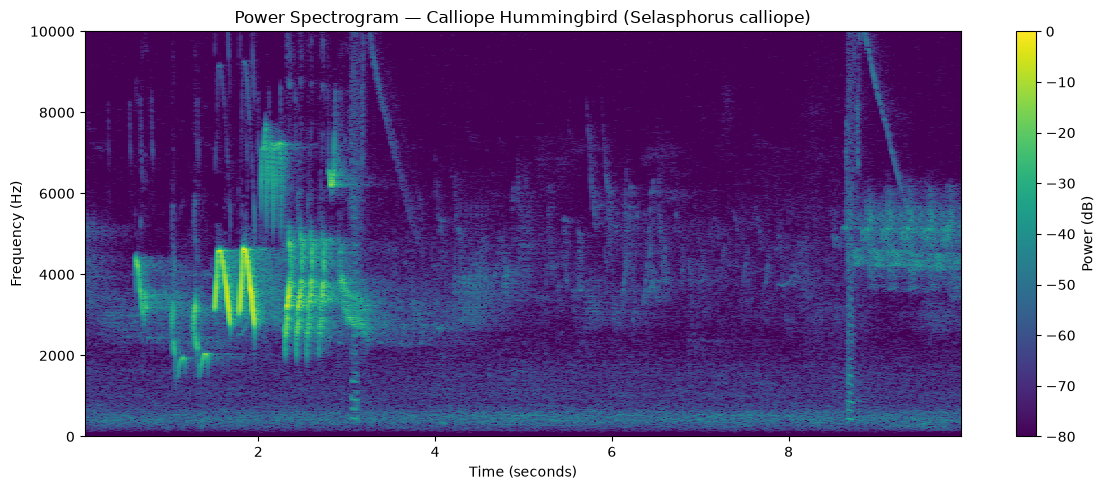

In [32]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))

S_db = librosa.power_to_db(
    S_power,
    ref=np.max
)

plt.pcolormesh(
    times,
    frequencies,
    S_db,
    shading="auto"
)

plt.ylim(
    FEATURE_CONFIG["ndsi_anthrophony_min_hz"],
    FEATURE_CONFIG["primary_frequency_max_hz"]
)

plt.xlabel("Time (seconds)")
plt.ylabel("Frequency (Hz)")
plt.title(
    f"Power Spectrogram — {row['common_name']} "
    f"({row['scientific_name']})"
)

plt.colorbar(label="Power (dB)")
plt.tight_layout()
plt.show()

In [33]:
def compute_power_spectrogram(
    y,
    sample_rate=22050,
    n_fft=2048,
    hop_length=512,
    window="hann",
    center=False
):
    """
    Compute a power spectrogram from a standardized audio window.

    Returns
    -------
    S_power : np.ndarray
        Power spectrogram.
    frequencies : np.ndarray
        Frequency values in Hz.
    times : np.ndarray
        Time values in seconds.
    """

    S = librosa.stft(
        y,
        n_fft=n_fft,
        hop_length=hop_length,
        window=window,
        center=center
    )

    S_power = np.abs(S) ** 2

    frequencies = librosa.fft_frequencies(
        sr=sample_rate,
        n_fft=n_fft
    )

    times = librosa.frames_to_time(
        np.arange(S_power.shape[1]),
        sr=sample_rate,
        hop_length=hop_length,
        n_fft=n_fft
    )

    return S_power, frequencies, times

In [34]:
S_power, frequencies, times = compute_power_spectrogram(
    y_window,
    sample_rate=FEATURE_CONFIG["analysis_sample_rate"],
    n_fft=SPECTROGRAM_CONFIG["n_fft"],
    hop_length=SPECTROGRAM_CONFIG["hop_length"],
    window=SPECTROGRAM_CONFIG["window"],
    center=SPECTROGRAM_CONFIG["center"]
)

print("Power spectrogram shape:", S_power.shape)
print("Frequency bins:", len(frequencies))
print("Time frames:", len(times))
print(
    f"Frequency range: "
    f"{frequencies.min():.1f}–{frequencies.max():.1f} Hz"
)
print(
    f"Time range: "
    f"{times.min():.3f}–{times.max():.3f} sec"
)

Power spectrogram shape: (1025, 427)
Frequency bins: 1025
Time frames: 427
Frequency range: 0.0–11025.0 Hz
Time range: 0.046–9.938 sec


In [35]:
def create_frequency_masks(
    frequencies,
    primary_min_hz=1000,
    primary_max_hz=10000,
    ndsi_anthro_min_hz=0,
    ndsi_anthro_max_hz=1000,
    ndsi_bio_min_hz=1000,
    ndsi_bio_max_hz=10000
):
    """
    Create reusable frequency masks for acoustic analysis.
    """

    primary_mask = (
        (frequencies >= primary_min_hz) &
        (frequencies <= primary_max_hz)
    )

    anthrophony_mask = (
        (frequencies >= ndsi_anthro_min_hz) &
        (frequencies < ndsi_anthro_max_hz)
    )

    biophony_mask = (
        (frequencies >= ndsi_bio_min_hz) &
        (frequencies <= ndsi_bio_max_hz)
    )

    return {
        "primary": primary_mask,
        "anthrophony": anthrophony_mask,
        "biophony": biophony_mask
    }

In [36]:
frequency_masks = create_frequency_masks(
    frequencies,
    primary_min_hz=FEATURE_CONFIG["primary_frequency_min_hz"],
    primary_max_hz=FEATURE_CONFIG["primary_frequency_max_hz"],
    ndsi_anthro_min_hz=FEATURE_CONFIG["ndsi_anthrophony_min_hz"],
    ndsi_anthro_max_hz=FEATURE_CONFIG["ndsi_anthrophony_max_hz"],
    ndsi_bio_min_hz=FEATURE_CONFIG["ndsi_biophony_min_hz"],
    ndsi_bio_max_hz=FEATURE_CONFIG["ndsi_biophony_max_hz"]
)

for name, mask in frequency_masks.items():
    selected_freqs = frequencies[mask]

    print(
        f"{name}: "
        f"{selected_freqs.min():.1f}–"
        f"{selected_freqs.max():.1f} Hz | "
        f"{mask.sum()} bins"
    )

primary: 1001.3–9991.4 Hz | 836 bins
anthrophony: 0.0–990.5 Hz | 93 bins
biophony: 1001.3–9991.4 Hz | 836 bins


In [37]:
import maad
import maad.features

In [38]:
primary_mask = frequency_masks["primary"]

S_primary = S_power[primary_mask, :]
fn_primary = frequencies[primary_mask]

print("Primary spectrogram shape:", S_primary.shape)
print(
    f"Primary frequency range: "
    f"{fn_primary.min():.1f}–{fn_primary.max():.1f} Hz"
)

Primary spectrogram shape: (836, 427)
Primary frequency range: 1001.3–9991.4 Hz


In [39]:
aci_result = maad.features.acoustic_complexity_index(
    S_primary
)

print("ACI result type:", type(aci_result))
print("ACI result:", aci_result)

ACI result type: <class 'tuple'>
ACI result: (array([[1.0971020e-06, 9.1748941e-04, 1.7883640e-05, ..., 3.5756782e-03,
        2.8827073e-04, 2.5206493e-04],
       [6.2835556e-05, 9.5940201e-04, 4.7657988e-04, ..., 3.7549948e-04,
        3.7313357e-04, 1.9446559e-03],
       [6.0329569e-04, 1.3091938e-03, 9.3085738e-04, ..., 2.5112936e-03,
        3.2562311e-03, 3.9677508e-03],
       ...,
       [1.5925032e-04, 1.8317467e-05, 1.7294650e-04, ..., 1.3248636e-05,
        4.5641686e-05, 7.0587892e-05],
       [5.6941307e-04, 6.9565082e-05, 5.6661008e-04, ..., 1.6769969e-04,
        6.6371613e-05, 3.1900839e-07],
       [4.8114256e-05, 6.6925764e-05, 2.0109514e-04, ..., 4.9892243e-04,
        3.3310211e-05, 1.1283439e-04]], shape=(836, 426), dtype=float32), array([0.8381206 , 0.7531161 , 0.80245864, 0.7946762 , 0.76057756,
       0.861905  , 0.98042   , 0.9256411 , 1.0022519 , 0.9696883 ,
       0.89269614, 0.9130567 , 0.77114516, 0.7750302 , 0.77227104,
       0.78159153, 0.79066443, 0.7

In [40]:
aci_per_bin, aci_per_time, aci_total = maad.features.acoustic_complexity_index(
    S_primary
)

print("ACI per-bin shape:", aci_per_bin.shape)
print("ACI per-time shape:", aci_per_time.shape)
print("ACI total:", float(aci_total))

print("\nACI per-bin:")
print(
    f"min={aci_per_bin.min():.6f}, "
    f"max={aci_per_bin.max():.6f}, "
    f"mean={aci_per_bin.mean():.6f}"
)

print("\nACI per-time:")
print(
    f"min={aci_per_time.min():.6f}, "
    f"max={aci_per_time.max():.6f}, "
    f"mean={aci_per_time.mean():.6f}"
)

ACI per-bin shape: (836, 426)
ACI per-time shape: (836,)
ACI total: 850.954833984375

ACI per-bin:
min=0.000000, max=0.535633, mean=0.002389

ACI per-time:
min=0.565651, max=1.336120, mean=1.017889


In [41]:
# Amplitude spectrogram for ACI
S_amplitude = np.abs(S)

S_primary_amplitude = S_amplitude[primary_mask, :]

aci_xx, aci_per_bin, aci_total = maad.features.acoustic_complexity_index(
    S_primary_amplitude
)

print("ACI matrix shape:", aci_xx.shape)
print("ACI per-frequency-bin shape:", aci_per_bin.shape)
print("ACI total:", float(aci_total))

print("\nACI matrix:")
print(
    f"min={aci_xx.min():.6f}, "
    f"max={aci_xx.max():.6f}, "
    f"mean={aci_xx.mean():.6f}"
)

print("\nACI per-frequency-bin:")
print(
    f"min={aci_per_bin.min():.6f}, "
    f"max={aci_per_bin.max():.6f}, "
    f"mean={aci_per_bin.mean():.6f}"
)

ACI matrix shape: (836, 426)
ACI per-frequency-bin shape: (836,)
ACI total: 510.2514343261719

ACI matrix:
min=0.000000, max=0.204841, mean=0.001433

ACI per-frequency-bin:
min=0.398562, max=0.857672, mean=0.610349


In [42]:
FEATURE_CONFIG["aci_input"] = "amplitude_spectrogram"

In [43]:
print("ACI input representation:", FEATURE_CONFIG["aci_input"])

ACI input representation: amplitude_spectrogram


In [44]:
adi_result = maad.features.acoustic_diversity_index(
    S_primary_amplitude,
    fn_primary,
    fmin=FEATURE_CONFIG["primary_frequency_min_hz"],
    fmax=FEATURE_CONFIG["primary_frequency_max_hz"],
    bin_step=1000,
    dB_threshold=-50,
    index="shannon"
)

print("ADI result type:", type(adi_result))
print("ADI result:", adi_result)

ADI result type: <class 'numpy.float64'>
ADI result: 1.661303607777536


In [45]:
bi_result = maad.features.bioacoustics_index(
    S_primary_amplitude,
    fn_primary,
    flim=(
        FEATURE_CONFIG["primary_frequency_min_hz"],
        FEATURE_CONFIG["primary_frequency_max_hz"]
    ),
    R_compatible="soundecology"
)

print("BI result type:", type(bi_result))
print("BI result:", bi_result)

BI result type: <class 'numpy.float64'>
BI result: 1443.3719727891157


In [46]:
spectral_entropy_result = maad.features.spectral_entropy(
    S_power,
    frequencies,
    flim=(
        FEATURE_CONFIG["primary_frequency_min_hz"],
        FEATURE_CONFIG["primary_frequency_max_hz"]
    )
)

print(
    "Spectral entropy result type:",
    type(spectral_entropy_result)
)

print(
    "Spectral entropy result:",
    spectral_entropy_result
)

Spectral entropy result type: <class 'tuple'>
Spectral entropy result: (np.float64(0.23940373581585084), np.float64(0.3331387677788997), np.float64(0.24483939639858732), np.float64(0.24836633099263727), np.float64(15.933483262394086), np.float64(3.257990619427098))


In [47]:
import inspect

print(inspect.signature(maad.features.spectral_entropy))
print()
print(inspect.getdoc(maad.features.spectral_entropy))

(Sxx, fn, flim=None, display=False)

Compute different entropies based on the average spectrum, its variance, 
and its maxima [1]_ [2]_    

Parameters
----------
Sxx : ndarray of floats
    Spectrogram (2d). 
    It is recommended to work with PSD to be consistent with energy conservation

fn : 1d ndarray of floats
    frequency vector

flim : tupple (fmin, fmax), optional, default is None
    Frequency band used to compute the spectral entropy.
    For instance, one may want to compute the spectral entropy for the 
    biophony bandwidth

display : boolean, optional, default is False
    Display the different spectra (mean, variance, covariance, max...)
    
Returns
-------     
EAS : scalar
    Entropy of Average Spectrum
ECU : scalar
    Entropy of spectral variance (along the time axis for each frequency)
ECV : scalar
    Entropy of Coefficient of Variation (along the time axis for each frequency)
EPS : scalar
    Entropy of spectral maxima (peaks) 
EPS_KURT : scalar
    Kurtosis 

In [48]:
FEATURE_CONFIG["spectral_entropy_input"] = "power_spectrogram"
FEATURE_CONFIG["spectral_entropy_fmin_hz"] = 1000
FEATURE_CONFIG["spectral_entropy_fmax_hz"] = 10000

print(
    "Spectral entropy:",
    FEATURE_CONFIG["spectral_entropy_input"],
    "|",
    FEATURE_CONFIG["spectral_entropy_fmin_hz"],
    "to",
    FEATURE_CONFIG["spectral_entropy_fmax_hz"],
    "Hz"
)

Spectral entropy: power_spectrogram | 1000 to 10000 Hz


In [49]:
temporal_entropy_result = maad.features.temporal_entropy(
    y_window,
    compatibility="QUT",
    mode="fast",
    Nt=512
)

print("Temporal entropy result type:", type(temporal_entropy_result))
print("Temporal entropy result:", temporal_entropy_result)

Temporal entropy result type: <class 'numpy.float64'>
Temporal entropy result: 0.574903702467777


In [50]:
FEATURE_CONFIG["temporal_entropy_input"] = "time_domain_signal"
FEATURE_CONFIG["temporal_entropy_compatibility"] = "QUT"
FEATURE_CONFIG["temporal_entropy_mode"] = "fast"
FEATURE_CONFIG["temporal_entropy_Nt"] = 512

print(
    "Temporal entropy:",
    FEATURE_CONFIG["temporal_entropy_input"],
    "| compatibility:",
    FEATURE_CONFIG["temporal_entropy_compatibility"],
    "| mode:",
    FEATURE_CONFIG["temporal_entropy_mode"],
    "| Nt:",
    FEATURE_CONFIG["temporal_entropy_Nt"]
)

Temporal entropy: time_domain_signal | compatibility: QUT | mode: fast | Nt: 512


In [51]:
ndsi_result = maad.features.soundscape_index(
    S_power,
    frequencies,
    flim_bioPh=(
        FEATURE_CONFIG["ndsi_biophony_min_hz"],
        FEATURE_CONFIG["ndsi_biophony_max_hz"]
    ),
    flim_antroPh=(
        FEATURE_CONFIG["ndsi_anthrophony_min_hz"],
        FEATURE_CONFIG["ndsi_anthrophony_max_hz"]
    ),
    R_compatible="soundecology"
)

print("NDSI result type:", type(ndsi_result))
print("NDSI result:", ndsi_result)

NDSI result type: <class 'tuple'>
NDSI result: (np.float64(0.9947542399937396), np.float64(380.26029357293385), np.float64(4426.61187244812), np.float64(1683264.7301505567))


In [52]:
FEATURE_CONFIG["ndsi_input"] = "power_spectrogram"
FEATURE_CONFIG["ndsi_biophony_band_hz"] = [1000, 10000]
FEATURE_CONFIG["ndsi_anthrophony_band_hz"] = [0, 1000]
FEATURE_CONFIG["ndsi_implementation"] = "maad.features.soundscape_index"
FEATURE_CONFIG["ndsi_compatibility"] = "soundecology"

print("NDSI configuration:")
print("Input:", FEATURE_CONFIG["ndsi_input"])
print("Biophony:", FEATURE_CONFIG["ndsi_biophony_band_hz"], "Hz")
print("Anthrophony:", FEATURE_CONFIG["ndsi_anthrophony_band_hz"], "Hz")
print("Implementation:", FEATURE_CONFIG["ndsi_implementation"])

NDSI configuration:
Input: power_spectrogram
Biophony: [1000, 10000] Hz
Anthrophony: [0, 1000] Hz
Implementation: maad.features.soundscape_index


In [53]:
sr = FEATURE_CONFIG["analysis_sample_rate"]

rms = librosa.feature.rms(
    y=y_window,
    frame_length=SPECTROGRAM_CONFIG["n_fft"],
    hop_length=SPECTROGRAM_CONFIG["hop_length"],
    center=SPECTROGRAM_CONFIG["center"]
)

zero_crossing = librosa.feature.zero_crossing_rate(
    y_window,
    frame_length=SPECTROGRAM_CONFIG["n_fft"],
    hop_length=SPECTROGRAM_CONFIG["hop_length"],
    center=SPECTROGRAM_CONFIG["center"]
)

spectral_centroid = librosa.feature.spectral_centroid(
    y=y_window,
    sr=sr,
    n_fft=SPECTROGRAM_CONFIG["n_fft"],
    hop_length=SPECTROGRAM_CONFIG["hop_length"],
    center=SPECTROGRAM_CONFIG["center"]
)

spectral_bandwidth = librosa.feature.spectral_bandwidth(
    y=y_window,
    sr=sr,
    n_fft=SPECTROGRAM_CONFIG["n_fft"],
    hop_length=SPECTROGRAM_CONFIG["hop_length"],
    center=SPECTROGRAM_CONFIG["center"]
)

spectral_rolloff = librosa.feature.spectral_rolloff(
    y=y_window,
    sr=sr,
    n_fft=SPECTROGRAM_CONFIG["n_fft"],
    hop_length=SPECTROGRAM_CONFIG["hop_length"],
    roll_percent=0.85,
    center=SPECTROGRAM_CONFIG["center"]
)

print("RMS shape:", rms.shape)
print("Zero-crossing shape:", zero_crossing.shape)
print("Spectral centroid shape:", spectral_centroid.shape)
print("Spectral bandwidth shape:", spectral_bandwidth.shape)
print("Spectral rolloff shape:", spectral_rolloff.shape)

print("\nSummary:")
print(f"RMS mean: {rms.mean():.6f}")
print(f"Zero-crossing mean: {zero_crossing.mean():.6f}")
print(f"Centroid mean: {spectral_centroid.mean():.2f} Hz")
print(f"Bandwidth mean: {spectral_bandwidth.mean():.2f} Hz")
print(f"Rolloff mean: {spectral_rolloff.mean():.2f} Hz")

RMS shape: (1, 427)
Zero-crossing shape: (1, 427)
Spectral centroid shape: (1, 427)
Spectral bandwidth shape: (1, 427)
Spectral rolloff shape: (1, 427)

Summary:
RMS mean: 0.028056
Zero-crossing mean: 0.258119
Centroid mean: 3264.57 Hz
Bandwidth mean: 2005.90 Hz
Rolloff mean: 5198.38 Hz


In [54]:
MFCC_CONFIG = {
    "n_mfcc": 13,
    "n_mels": 40,
    "fmin_hz": 1000,
    "fmax_hz": 10000,
    "n_fft": SPECTROGRAM_CONFIG["n_fft"],
    "hop_length": SPECTROGRAM_CONFIG["hop_length"],
    "window": SPECTROGRAM_CONFIG["window"],
    "center": SPECTROGRAM_CONFIG["center"],
}

FEATURE_CONFIG["mfcc"] = MFCC_CONFIG

print(json.dumps(MFCC_CONFIG, indent=2))

{
  "n_mfcc": 13,
  "n_mels": 40,
  "fmin_hz": 1000,
  "fmax_hz": 10000,
  "n_fft": 2048,
  "hop_length": 512,
  "window": "hann",
  "center": false
}


In [55]:
mfcc = librosa.feature.mfcc(
    y=y_window,
    sr=sr,
    n_mfcc=MFCC_CONFIG["n_mfcc"],
    n_fft=MFCC_CONFIG["n_fft"],
    hop_length=MFCC_CONFIG["hop_length"],
    n_mels=MFCC_CONFIG["n_mels"],
    fmin=MFCC_CONFIG["fmin_hz"],
    fmax=MFCC_CONFIG["fmax_hz"],
    window=MFCC_CONFIG["window"],
    center=MFCC_CONFIG["center"],
)

print("MFCC shape:", mfcc.shape)

print("\nMFCC summary:")
for i in range(mfcc.shape[0]):
    print(
        f"MFCC {i+1:02d}: "
        f"mean={mfcc[i].mean():.4f}, "
        f"std={mfcc[i].std():.4f}, "
        f"min={mfcc[i].min():.4f}, "
        f"max={mfcc[i].max():.4f}"
    )

MFCC shape: (13, 427)

MFCC summary:
MFCC 01: mean=-222.2806, std=39.8840, min=-269.9106, max=-99.6827
MFCC 02: mean=18.9911, std=19.9779, min=-41.2662, max=77.0076
MFCC 03: mean=-33.0566, std=25.8829, min=-108.6146, max=6.7883
MFCC 04: mean=20.8755, std=17.2245, min=-32.8630, max=61.6698
MFCC 05: mean=5.9784, std=16.7841, min=-32.0672, max=60.1785
MFCC 06: mean=-3.8592, std=13.2297, min=-55.0797, max=47.9532
MFCC 07: mean=-2.5174, std=11.8082, min=-45.1440, max=39.3168
MFCC 08: mean=0.5139, std=10.4640, min=-26.0556, max=41.0216
MFCC 09: mean=0.7753, std=7.4131, min=-23.0365, max=19.9667
MFCC 10: mean=2.3522, std=5.2413, min=-18.8196, max=22.7588
MFCC 11: mean=0.3324, std=5.0946, min=-17.1661, max=17.1002
MFCC 12: mean=-0.0995, std=4.9987, min=-16.3113, max=14.0405
MFCC 13: mean=0.8813, std=5.1245, min=-14.9029, max=20.6092


In [56]:
FEATURE_CONFIG.update({
    # General spectral features
    "rms_input": "time_domain_signal",
    "zero_crossing_rate_input": "time_domain_signal",
    "spectral_centroid_input": "librosa",
    "spectral_bandwidth_input": "librosa",
    "spectral_rolloff_input": "librosa",
    "spectral_rolloff_percent": 0.85,

    # MFCC
    "mfcc_n_mfcc": 13,
    "mfcc_n_mels": 40,
    "mfcc_fmin_hz": 1000,
    "mfcc_fmax_hz": 10000,
    "mfcc_input": "log_mel_spectrogram",
})

print(json.dumps(FEATURE_CONFIG, indent=2))

{
  "analysis_sample_rate": 22050,
  "target_channels": 1,
  "resampling_method": "soxr_hq",
  "primary_frequency_min_hz": 1000,
  "primary_frequency_max_hz": 10000,
  "ndsi_biophony_min_hz": 1000,
  "ndsi_biophony_max_hz": 10000,
  "ndsi_anthrophony_min_hz": 0,
  "ndsi_anthrophony_max_hz": 1000,
  "window_seconds": 10.0,
  "window_overlap": 0.0,
  "short_recording_policy": "use_entire_recording",
  "padding": false,
  "looping": false,
  "random_seed": 42,
  "aci_input": "amplitude_spectrogram",
  "spectral_entropy_input": "power_spectrogram",
  "spectral_entropy_fmin_hz": 1000,
  "spectral_entropy_fmax_hz": 10000,
  "temporal_entropy_input": "time_domain_signal",
  "temporal_entropy_compatibility": "QUT",
  "temporal_entropy_mode": "fast",
  "temporal_entropy_Nt": 512,
  "ndsi_input": "power_spectrogram",
  "ndsi_biophony_band_hz": [
    1000,
    10000
  ],
  "ndsi_anthrophony_band_hz": [
    0,
    1000
  ],
  "ndsi_implementation": "maad.features.soundscape_index",
  "ndsi_compati

In [130]:
def extract_window_features(
    y_window,
    sample_rate=22050,
    feature_config=FEATURE_CONFIG,
    spectrogram_config=SPECTROGRAM_CONFIG,
    mfcc_config=MFCC_CONFIG
):
    """
    Extract acoustic, spectral, entropy, and MFCC features
    from a single standardized analysis window.

    Returns
    -------
    dict
        Recording/window-level feature values.
    """

    # ---------------------------------------------------------
    # 1. Power spectrogram
    # ---------------------------------------------------------
    S_power, frequencies, times = compute_power_spectrogram(
        y_window,
        sample_rate=sample_rate,
        n_fft=spectrogram_config["n_fft"],
        hop_length=spectrogram_config["hop_length"],
        window=spectrogram_config["window"],
        center=spectrogram_config["center"]
    )

    # Amplitude spectrogram for ACI / ADI / BI
    S_amplitude = np.sqrt(S_power)

    # ---------------------------------------------------------
    # 2. Frequency masks
    # ---------------------------------------------------------
    masks = create_frequency_masks(
        frequencies,
        primary_min_hz=feature_config["primary_frequency_min_hz"],
        primary_max_hz=feature_config["primary_frequency_max_hz"],
        ndsi_anthro_min_hz=feature_config["ndsi_anthrophony_min_hz"],
        ndsi_anthro_max_hz=feature_config["ndsi_anthrophony_max_hz"],
        ndsi_bio_min_hz=feature_config["ndsi_biophony_min_hz"],
        ndsi_bio_max_hz=feature_config["ndsi_biophony_max_hz"]
    )

    primary_mask = masks["primary"]

    S_primary_amplitude = S_amplitude[primary_mask, :]
    fn_primary = frequencies[primary_mask]

    # ---------------------------------------------------------
    # 3. ACI
    # ---------------------------------------------------------
    _, _, aci_total = maad.features.acoustic_complexity_index(
        S_primary_amplitude
    )

    # ---------------------------------------------------------
    # 4. ADI
    # ---------------------------------------------------------
    adi = maad.features.acoustic_diversity_index(
        S_primary_amplitude,
        fn_primary,
        fmin=feature_config["primary_frequency_min_hz"],
        fmax=feature_config["primary_frequency_max_hz"],
        bin_step=1000,
        dB_threshold=-50,
        index="shannon"
    )

    # ---------------------------------------------------------
    # 5. Bioacoustic Index
    # ---------------------------------------------------------
    bi = maad.features.bioacoustics_index(
        S_primary_amplitude,
        fn_primary,
        flim=(
            feature_config["primary_frequency_min_hz"],
            feature_config["primary_frequency_max_hz"]
        ),
        R_compatible="soundecology"
    )

    # ---------------------------------------------------------
    # 6. Spectral entropy
    # ---------------------------------------------------------
    spectral_entropy = maad.features.spectral_entropy(
        S_power,
        frequencies,
        flim=(
            feature_config["spectral_entropy_fmin_hz"],
            feature_config["spectral_entropy_fmax_hz"]
        )
    )

    (
        spectral_entropy_eas,
        spectral_entropy_ecu,
        spectral_entropy_ecv,
        spectral_entropy_eps,
        spectral_entropy_eps_kurt,
        spectral_entropy_eps_skew
    ) = spectral_entropy

    # ---------------------------------------------------------
    # 7. Temporal entropy
    # ---------------------------------------------------------
    # scikit-maad temporal_entropy can encounter float32 underflow
# when replacing zero PMF values with its minimum probability.
# float64 preserves the intended numerical calculation.
    temporal_entropy = maad.features.temporal_entropy(
    y_window.astype(np.float64),
    compatibility=feature_config["temporal_entropy_compatibility"],
    mode=feature_config["temporal_entropy_mode"],
    Nt=feature_config["temporal_entropy_Nt"]
)
    # ---------------------------------------------------------
    # 8. NDSI
    # ---------------------------------------------------------
    ndsi, ratio_ba, anthropophony, biophony = (
        maad.features.soundscape_index(
            S_power,
            frequencies,
            flim_bioPh=(
                feature_config["ndsi_biophony_min_hz"],
                feature_config["ndsi_biophony_max_hz"]
            ),
            flim_antroPh=(
                feature_config["ndsi_anthrophony_min_hz"],
                feature_config["ndsi_anthrophony_max_hz"]
            ),
            R_compatible=feature_config["ndsi_compatibility"]
        )
    )

    # ---------------------------------------------------------
    # 9. General spectral features
    # ---------------------------------------------------------
    rms = librosa.feature.rms(
        y=y_window,
        frame_length=spectrogram_config["n_fft"],
        hop_length=spectrogram_config["hop_length"],
        center=spectrogram_config["center"]
    )

    zero_crossing = librosa.feature.zero_crossing_rate(
        y_window,
        frame_length=spectrogram_config["n_fft"],
        hop_length=spectrogram_config["hop_length"],
        center=spectrogram_config["center"]
    )

    spectral_centroid = librosa.feature.spectral_centroid(
        y=y_window,
        sr=sample_rate,
        n_fft=spectrogram_config["n_fft"],
        hop_length=spectrogram_config["hop_length"],
        center=spectrogram_config["center"]
    )

    spectral_bandwidth = librosa.feature.spectral_bandwidth(
        y=y_window,
        sr=sample_rate,
        n_fft=spectrogram_config["n_fft"],
        hop_length=spectrogram_config["hop_length"],
        center=spectrogram_config["center"]
    )

    spectral_rolloff = librosa.feature.spectral_rolloff(
        y=y_window,
        sr=sample_rate,
        n_fft=spectrogram_config["n_fft"],
        hop_length=spectrogram_config["hop_length"],
        roll_percent=feature_config["spectral_rolloff_percent"],
        center=spectrogram_config["center"]
    )

    # ---------------------------------------------------------
    # 10. MFCCs
    # ---------------------------------------------------------
    mfcc = librosa.feature.mfcc(
        y=y_window,
        sr=sample_rate,
        n_mfcc=mfcc_config["n_mfcc"],
        n_fft=mfcc_config["n_fft"],
        hop_length=mfcc_config["hop_length"],
        n_mels=mfcc_config["n_mels"],
        fmin=mfcc_config["fmin_hz"],
        fmax=mfcc_config["fmax_hz"],
        window=mfcc_config["window"],
        center=mfcc_config["center"]
    )

    # ---------------------------------------------------------
    # 11. Assemble recording/window-level features
    # ---------------------------------------------------------
    features = {
        "window_duration_seconds": len(y_window) / sample_rate,

        # Ecological acoustic indices
        "aci": float(aci_total),
        "adi": float(adi),
        "bioacoustic_index": float(bi),
        "ndsi": float(ndsi),
        "ndsi_ratio_ba": float(ratio_ba),
        "anthropophony": float(anthropophony),
        "biophony": float(biophony),

        # Entropy
        "spectral_entropy_eas": float(spectral_entropy_eas),
        "spectral_entropy_ecu": float(spectral_entropy_ecu),
        "spectral_entropy_ecv": float(spectral_entropy_ecv),
        "spectral_entropy_eps": float(spectral_entropy_eps),
        "spectral_entropy_eps_kurt": float(spectral_entropy_eps_kurt),
        "spectral_entropy_eps_skew": float(spectral_entropy_eps_skew),
        "temporal_entropy": float(temporal_entropy),

        # General acoustic features
        "rms_mean": float(rms.mean()),
        "rms_std": float(rms.std()),
        "zcr_mean": float(zero_crossing.mean()),
        "zcr_std": float(zero_crossing.std()),
        "spectral_centroid_mean": float(spectral_centroid.mean()),
        "spectral_centroid_std": float(spectral_centroid.std()),
        "spectral_bandwidth_mean": float(spectral_bandwidth.mean()),
        "spectral_bandwidth_std": float(spectral_bandwidth.std()),
        "spectral_rolloff_mean": float(spectral_rolloff.mean()),
        "spectral_rolloff_std": float(spectral_rolloff.std()),
    }

    # ---------------------------------------------------------
    # 12. MFCC summary statistics
    # ---------------------------------------------------------
    for i in range(mfcc.shape[0]):
        coefficient = i + 1

        features[f"mfcc_{coefficient:02d}_mean"] = float(
            mfcc[i].mean()
        )

        features[f"mfcc_{coefficient:02d}_std"] = float(
            mfcc[i].std()
        )

    return features

In [58]:
test_features = extract_window_features(
    y_window,
    sample_rate=FEATURE_CONFIG["analysis_sample_rate"]
)

test_features_df = pd.DataFrame([test_features])

print("Number of extracted features:", len(test_features))
print("\nFeature names:")
print(test_features_df.columns.tolist())

print("\nFeature values:")
display(test_features_df.T)

Number of extracted features: 51

Feature names:
['window_duration_seconds', 'aci', 'adi', 'bioacoustic_index', 'ndsi', 'ndsi_ratio_ba', 'anthropophony', 'biophony', 'spectral_entropy_eas', 'spectral_entropy_ecu', 'spectral_entropy_ecv', 'spectral_entropy_eps', 'spectral_entropy_eps_kurt', 'spectral_entropy_eps_skew', 'temporal_entropy', 'rms_mean', 'rms_std', 'zcr_mean', 'zcr_std', 'spectral_centroid_mean', 'spectral_centroid_std', 'spectral_bandwidth_mean', 'spectral_bandwidth_std', 'spectral_rolloff_mean', 'spectral_rolloff_std', 'mfcc_01_mean', 'mfcc_01_std', 'mfcc_02_mean', 'mfcc_02_std', 'mfcc_03_mean', 'mfcc_03_std', 'mfcc_04_mean', 'mfcc_04_std', 'mfcc_05_mean', 'mfcc_05_std', 'mfcc_06_mean', 'mfcc_06_std', 'mfcc_07_mean', 'mfcc_07_std', 'mfcc_08_mean', 'mfcc_08_std', 'mfcc_09_mean', 'mfcc_09_std', 'mfcc_10_mean', 'mfcc_10_std', 'mfcc_11_mean', 'mfcc_11_std', 'mfcc_12_mean', 'mfcc_12_std', 'mfcc_13_mean', 'mfcc_13_std']

Feature values:


,0
window_duration_seconds,1.000000e+01
aci,5.102514e+02
adi,1.661304e+00
bioacoustic_index,1.443372e+03
ndsi,9.947542e-01
ndsi_ratio_ba,3.802603e+02
anthropophony,4.426612e+03
biophony,1.683265e+06
spectral_entropy_eas,2.394037e-01
spectral_entropy_ecu,3.331388e-01


In [59]:
TEST_RECORDING_ID = "1152009"
TEST_STATE = "CA"

test_audio_path = AUDIO_DIR / f"{TEST_STATE}_{TEST_RECORDING_ID}.mp3"

y_test, original_sr, original_channels = load_standardized_audio(
    test_audio_path,
    target_sr=FEATURE_CONFIG["analysis_sample_rate"]
)

test_windows = create_analysis_windows(
    y_test,
    sample_rate=FEATURE_CONFIG["analysis_sample_rate"],
    window_seconds=FEATURE_CONFIG["window_seconds"]
)

print("Recording:", TEST_RECORDING_ID)
print("Original sample rate:", original_sr)
print("Original channels:", original_channels)
print("Standardized duration:", len(y_test) / FEATURE_CONFIG["analysis_sample_rate"])
print("Number of windows:", len(test_windows))

display(pd.DataFrame(test_windows))

Recording: 1152009
Original sample rate: 48000
Original channels: 1
Standardized duration: 20.077006802721087
Number of windows: 2


,window_index,start_sample,end_sample,window_start_seconds,window_end_seconds,window_duration_used,flag_short_window
0,0,0,220500,0.0,10.0,10.0,False
1,1,220500,441000,10.0,20.0,10.0,False


In [60]:
test_window_features = []

for window_info in test_windows:
    start = window_info["start_sample"]
    end = window_info["end_sample"]

    y_window_test = y_test[start:end]

    features = extract_window_features(
        y_window_test,
        sample_rate=FEATURE_CONFIG["analysis_sample_rate"]
    )

    # Add window metadata
    features.update({
        "state": TEST_STATE,
        "recording_id": TEST_RECORDING_ID,
        "window_index": window_info["window_index"],
        "window_start_seconds": window_info["window_start_seconds"],
        "window_end_seconds": window_info["window_end_seconds"],
        "window_duration_used": window_info["window_duration_used"],
        "flag_short_window": window_info["flag_short_window"],
    })

    test_window_features.append(features)

test_window_df = pd.DataFrame(test_window_features)

print("Window-level shape:", test_window_df.shape)

display(
    test_window_df[
        [
            "state",
            "recording_id",
            "window_index",
            "window_start_seconds",
            "window_end_seconds",
            "window_duration_used",
            "flag_short_window",
            "aci",
            "adi",
            "bioacoustic_index",
            "ndsi",
            "temporal_entropy",
            "rms_mean",
            "spectral_centroid_mean",
            "mfcc_01_mean"
        ]
    ]
)

Window-level shape: (2, 58)


,state,recording_id,window_index,window_start_seconds,window_end_seconds,window_duration_used,flag_short_window,aci,adi,bioacoustic_index,ndsi,temporal_entropy,rms_mean,spectral_centroid_mean,mfcc_01_mean
0,CA,1152009,0,0.0,10.0,10.0,False,510.251434,1.661304,1443.371973,0.994754,0.574904,0.028056,3264.570252,-222.280579
1,CA,1152009,1,10.0,20.0,10.0,False,480.362366,1.936778,1245.056689,0.923103,0.713653,0.010767,3347.064397,-226.533524


In [61]:
all_window_features = []
extraction_errors = []

for idx, row in master_metadata.iterrows():

    recording_id = str(row["recording_id"])
    state = str(row["state"])
    audio_path = AUDIO_DIR / f"{state}_{recording_id}.mp3"

    try:
        # ---------------------------------------------
        # Load and standardize audio
        # ---------------------------------------------
        y, original_sr, original_channels = load_standardized_audio(
            audio_path,
            target_sr=FEATURE_CONFIG["analysis_sample_rate"]
        )

        # ---------------------------------------------
        # Create analysis windows
        # ---------------------------------------------
        windows = create_analysis_windows(
            y,
            sample_rate=FEATURE_CONFIG["analysis_sample_rate"],
            window_seconds=FEATURE_CONFIG["window_seconds"]
        )

        # ---------------------------------------------
        # Extract features from each window
        # ---------------------------------------------
        for window_info in windows:

            start = window_info["start_sample"]
            end = window_info["end_sample"]

            y_window = y[start:end]

            features = extract_window_features(
                y_window,
                sample_rate=FEATURE_CONFIG["analysis_sample_rate"]
            )

            # -----------------------------------------
            # Recording / window metadata
            # -----------------------------------------
            features.update({
                "state": state,
                "recording_id": recording_id,
                "species_id": row["species_id"],
                "common_name": row["common_name"],
                "scientific_name": row["scientific_name"],

                "window_index": window_info["window_index"],
                "window_start_seconds": window_info["window_start_seconds"],
                "window_end_seconds": window_info["window_end_seconds"],
                "window_duration_used": window_info["window_duration_used"],
                "flag_short_window": window_info["flag_short_window"],

                # Original audio provenance
                "original_sample_rate": original_sr,
                "original_channels": original_channels,

                # Existing audit flags
                "flag_short_duration": row["flag_short_duration"],
                "flag_low_amplitude": row["flag_low_amplitude"],
                "flag_clipping": row["flag_clipping"],
                "flag_low_quality": row["flag_low_quality"],
                "flag_any": row["flag_any"],
                "flag_bandlimit_incompatible": (
                    original_sr < 20000
                ),
            })

            all_window_features.append(features)

    except Exception as e:

        extraction_errors.append({
            "recording_id": recording_id,
            "state": state,
            "audio_path": str(audio_path),
            "error_type": type(e).__name__,
            "error_message": str(e)
        })

    # Progress indicator
    if (idx + 1) % 25 == 0 or (idx + 1) == len(master_metadata):
        print(
            f"Processed {idx + 1}/{len(master_metadata)} recordings | "
            f"windows extracted: {len(all_window_features)} | "
            f"errors: {len(extraction_errors)}"
        )

c:\Users\Samanwita\Downloads\from-soundscapes-to-biodiversity\venv\Lib\site-packages\maad\util\math_func.py:439: RuntimeWarning: divide by zero encountered in log
  H = -np.sum(pmf*np.log(pmf),axis)/np.log(n)
c:\Users\Samanwita\Downloads\from-soundscapes-to-biodiversity\venv\Lib\site-packages\maad\util\math_func.py:439: RuntimeWarning: invalid value encountered in multiply
  H = -np.sum(pmf*np.log(pmf),axis)/np.log(n)
c:\Users\Samanwita\Downloads\from-soundscapes-to-biodiversity\venv\Lib\site-packages\maad\util\miscellaneous.py:358: RuntimeWarning: divide by zero encountered in log10
  y = 20*log10(x)   # take log


Processed 25/275 recordings | windows extracted: 66 | errors: 0
Processed 50/275 recordings | windows extracted: 177 | errors: 0
Processed 75/275 recordings | windows extracted: 279 | errors: 0
Processed 100/275 recordings | windows extracted: 394 | errors: 0
Processed 125/275 recordings | windows extracted: 528 | errors: 0
Processed 150/275 recordings | windows extracted: 695 | errors: 0
Processed 175/275 recordings | windows extracted: 846 | errors: 0
Processed 200/275 recordings | windows extracted: 940 | errors: 0
Processed 225/275 recordings | windows extracted: 1012 | errors: 0
Processed 250/275 recordings | windows extracted: 1115 | errors: 0
Processed 275/275 recordings | windows extracted: 1179 | errors: 0


In [62]:
acoustic_features_window = pd.DataFrame(all_window_features)
extraction_errors_df = pd.DataFrame(extraction_errors)

print("Window-level shape:", acoustic_features_window.shape)
print("Extraction errors:", len(extraction_errors_df))

print("\nUnique recordings:")
print(acoustic_features_window["recording_id"].nunique())

print("\nWindows by state:")
display(
    acoustic_features_window
    .groupby("state")["recording_id"]
    .nunique()
)

print("\nShort windows:")
print(
    acoustic_features_window["flag_short_window"]
    .value_counts(dropna=False)
)

Window-level shape: (1179, 69)
Extraction errors: 0

Unique recordings:
275

Windows by state:


state
AZ     75
CA    100
TX    100
Name: recording_id, dtype: int64


Short windows:
flag_short_window
False    1126
True       53
Name: count, dtype: int64


In [63]:
feature_columns = [
    col for col in acoustic_features_window.columns
    if col not in {
        "state",
        "recording_id",
        "species_id",
        "common_name",
        "scientific_name"
    }
]

nan_counts = acoustic_features_window[feature_columns].isna().sum()
inf_counts = np.isinf(
    acoustic_features_window[feature_columns].select_dtypes(
        include=np.number
    )
).sum()

print("Columns containing NaN:")
display(nan_counts[nan_counts > 0])

print("\nColumns containing inf:")
display(inf_counts[inf_counts > 0])

Columns containing NaN:


temporal_entropy    44
dtype: int64


Columns containing inf:


Series([], dtype: int64)

In [64]:
temporal_nan_rows = acoustic_features_window[
    acoustic_features_window["temporal_entropy"].isna()
].copy()

print("Number of NaN temporal-entropy windows:", len(temporal_nan_rows))

display(
    temporal_nan_rows[
        [
            "state",
            "recording_id",
            "species_id",
            "window_index",
            "window_duration_used",
            "flag_short_window",
            "flag_short_duration",
            "flag_low_amplitude",
            "flag_clipping",
            "flag_any",
            "original_sample_rate",
            "original_channels"
        ]
    ].sort_values(
        ["window_duration_used", "state", "recording_id"]
    )
)

Number of NaN temporal-entropy windows: 44


,state,recording_id,species_id,window_index,window_duration_used,flag_short_window,flag_short_duration,flag_low_amplitude,flag_clipping,flag_any,original_sample_rate,original_channels
0,CA,375492,Streptopelia roseogrisea,0,5.251701,True,False,False,False,False,44100,2
405,AZ,452506,Calypte anna,0,5.448027,True,False,False,False,False,48000,1
95,CA,163986,Geococcyx californianus,0,6.048027,True,False,True,False,True,48000,1
967,TX,278460,Chaetura pelagica,0,6.864036,True,False,True,False,True,48000,1
785,AZ,453887,Anser albifrons,0,7.176009,True,False,False,False,False,48000,1
978,TX,147312,Buteogallus anthracinus,0,7.344036,True,False,True,False,True,48000,1
1079,TX,453004,Tringa melanoleuca,0,8.328027,True,False,False,False,False,48000,1
864,TX,147270,Fulica americana,0,9.792018,True,False,True,False,True,48000,1
260,CA,375491,Streptopelia roseogrisea,0,9.901497,True,False,False,False,False,44100,2
514,AZ,453885,Anser albifrons,0,10.000000,False,False,False,False,False,48000,1


In [65]:
print("NaN temporal entropy by window type:")

display(
    temporal_nan_rows[
        "flag_short_window"
    ].value_counts(dropna=False)
)

print("\nNaN temporal entropy by duration:")

display(
    temporal_nan_rows[
        "window_duration_used"
    ].describe()
)

print("\nShortest NaN windows:")

display(
    temporal_nan_rows[
        [
            "state",
            "recording_id",
            "window_index",
            "window_duration_used",
            "flag_short_window"
        ]
    ]
    .sort_values("window_duration_used")
    .head(20)
)

NaN temporal entropy by window type:


flag_short_window
False    35
True      9
Name: count, dtype: int64


NaN temporal entropy by duration:


count    44.000000
mean      9.458031
std       1.308937
min       5.251701
25%      10.000000
50%      10.000000
75%      10.000000
max      10.000000
Name: window_duration_used, dtype: float64


Shortest NaN windows:


,state,recording_id,window_index,window_duration_used,flag_short_window
0,CA,375492,0,5.251701,True
405,AZ,452506,0,5.448027,True
95,CA,163986,0,6.048027,True
967,TX,278460,0,6.864036,True
785,AZ,453887,0,7.176009,True
978,TX,147312,0,7.344036,True
1079,TX,453004,0,8.328027,True
864,TX,147270,0,9.792018,True
260,CA,375491,0,9.901497,True
146,CA,286968,0,10.000000,False


In [66]:
# Select representative NaN cases
nan_temporal = acoustic_features_window[
    acoustic_features_window["temporal_entropy"].isna()
].copy()

clean_nan = nan_temporal[
    (~nan_temporal["flag_any"]) &
    (~nan_temporal["flag_short_window"])
].iloc[0]

flagged_nan = nan_temporal[
    (nan_temporal["flag_any"]) &
    (~nan_temporal["flag_short_window"])
].iloc[0]

short_nan = nan_temporal[
    nan_temporal["flag_short_window"]
].iloc[0]

# Find a normal finite example
finite_example = acoustic_features_window[
    (~acoustic_features_window["temporal_entropy"].isna()) &
    (~acoustic_features_window["flag_short_window"])
].iloc[0]

print("Clean 10-sec NaN:")
print(
    clean_nan[
        ["state", "recording_id", "window_index",
         "window_duration_used", "flag_any"]
    ]
)

print("\nFlagged 10-sec NaN:")
print(
    flagged_nan[
        ["state", "recording_id", "window_index",
         "window_duration_used", "flag_any",
         "flag_low_amplitude", "flag_clipping"]
    ]
)

print("\nShort NaN:")
print(
    short_nan[
        ["state", "recording_id", "window_index",
         "window_duration_used", "flag_any"]
    ]
)

print("\nFinite control:")
print(
    finite_example[
        ["state", "recording_id", "window_index",
         "window_duration_used", "temporal_entropy"]
    ]
)

Clean 10-sec NaN:
state                       CA
recording_id            452094
window_index                 0
window_duration_used      10.0
flag_any                 False
Name: 4, dtype: object

Flagged 10-sec NaN:
state                       CA
recording_id            286971
window_index                 0
window_duration_used      10.0
flag_any                  True
flag_low_amplitude        True
flag_clipping            False
Name: 52, dtype: object

Short NaN:
state                         CA
recording_id              375492
window_index                   0
window_duration_used    5.251701
flag_any                   False
Name: 0, dtype: object

Finite control:
state                         CA
recording_id              952203
window_index                   0
window_duration_used        10.0
temporal_entropy        0.923827
Name: 1, dtype: object


In [68]:
# Recreate the four representative cases

nan_temporal = acoustic_features_window[
    acoustic_features_window["temporal_entropy"].isna()
].copy()

# 1. Clean 10-second NaN
clean_nan = nan_temporal[
    (~nan_temporal["flag_any"]) &
    (~nan_temporal["flag_short_window"])
].iloc[0]

# 2. Flagged 10-second NaN
flagged_nan = nan_temporal[
    (nan_temporal["flag_any"]) &
    (~nan_temporal["flag_short_window"])
].iloc[0]

# 3. Short NaN
short_nan = nan_temporal[
    nan_temporal["flag_short_window"]
].iloc[0]

# 4. Finite 10-second control
finite_example = acoustic_features_window[
    (~acoustic_features_window["temporal_entropy"].isna()) &
    (~acoustic_features_window["flag_short_window"])
].iloc[0]


def inspect_temporal_entropy_case(case_row):

    state = str(case_row["state"])
    recording_id = str(case_row["recording_id"])
    window_index = int(case_row["window_index"])

    audio_path = AUDIO_DIR / f"{state}_{recording_id}.mp3"

    y, sr_original, channels = load_standardized_audio(
        audio_path,
        target_sr=FEATURE_CONFIG["analysis_sample_rate"]
    )

    windows = create_analysis_windows(
        y,
        sample_rate=FEATURE_CONFIG["analysis_sample_rate"],
        window_seconds=FEATURE_CONFIG["window_seconds"]
    )

    window_info = windows[window_index]

    y_case = y[
        window_info["start_sample"]:
        window_info["end_sample"]
    ]

    te = maad.features.temporal_entropy(
        y_case,
        compatibility=FEATURE_CONFIG["temporal_entropy_compatibility"],
        mode=FEATURE_CONFIG["temporal_entropy_mode"],
        Nt=FEATURE_CONFIG["temporal_entropy_Nt"]
    )

    return {
        "state": state,
        "recording_id": recording_id,
        "window_index": window_index,
        "duration": len(y_case) / FEATURE_CONFIG["analysis_sample_rate"],
        "n_samples": len(y_case),
        "min": float(np.min(y_case)),
        "max": float(np.max(y_case)),
        "mean": float(np.mean(y_case)),
        "std": float(np.std(y_case)),
        "rms": float(np.sqrt(np.mean(y_case ** 2))),
        "nonzero_samples": int(np.count_nonzero(y_case)),
        "unique_values": int(np.unique(y_case).size),
        "temporal_entropy": te,
    }


cases = [
    ("clean_10s_nan", clean_nan),
    ("flagged_10s_nan", flagged_nan),
    ("short_nan", short_nan),
    ("finite_control", finite_example),
]

diagnostic_results = []

for label, case in cases:
    result = inspect_temporal_entropy_case(case)
    result["case"] = label
    diagnostic_results.append(result)

diagnostic_df = pd.DataFrame(diagnostic_results)

display(diagnostic_df)

c:\Users\Samanwita\Downloads\from-soundscapes-to-biodiversity\venv\Lib\site-packages\maad\util\math_func.py:439: RuntimeWarning: divide by zero encountered in log
  H = -np.sum(pmf*np.log(pmf),axis)/np.log(n)
c:\Users\Samanwita\Downloads\from-soundscapes-to-biodiversity\venv\Lib\site-packages\maad\util\math_func.py:439: RuntimeWarning: invalid value encountered in multiply
  H = -np.sum(pmf*np.log(pmf),axis)/np.log(n)


,state,recording_id,window_index,duration,n_samples,min,max,mean,std,rms,nonzero_samples,unique_values,temporal_entropy,case
0,CA,452094,0,10.000000,220500,-0.485833,0.681696,6.470055e-06,0.020079,0.020079,219029,218753,NaN,clean_10s_nan
1,CA,286971,0,10.000000,220500,-0.028702,0.029347,4.580155e-06,0.003988,0.003988,219029,218799,NaN,flagged_10s_nan
2,CA,375492,0,5.251701,115800,-0.071197,0.064964,-4.751202e-06,0.010714,0.010714,114905,114361,NaN,short_nan
3,CA,952203,0,10.000000,220500,-0.089778,0.094995,7.192860e-08,0.008258,0.008258,220500,220158,0.923827,finite_control


In [69]:
import inspect

print(inspect.getsource(maad.features.temporal_entropy))

def temporal_entropy (s, compatibility="QUT", mode ='fast', Nt=512) :
    """
    Computes the entropy of the envelope of an audio signal.

    Parameters
    ----------
    s : 1D array
        Audio to process (wav)
        compatibility : string {'QUT', 'seewave'}, default is 'QUT'
        Select the way to compute the temporal entropy.
        
        - QUT [2]_: entropy of the squared envelope
        - seewave [1]_ : entropy of the envelope
    mode : str, optional, default is "fast"
        Select the mode to compute the envelope of the audio waveform.
        
        - "fast" : The sound is first divided into frames (2d) using the function _wave2timeframes(s), then the max of each frame gives a good approximation of the envelope.
        - "Hilbert" : estimation of the envelope from the Hilbert transform. The method is slow.
    Nt : integer, optional, default is 512
        Size of each frame. The largest, the highest is the approximation.

    Returns
    -------
    Ht: fl

In [70]:
source = inspect.getsource(maad.features.temporal_entropy)

print(source)

def temporal_entropy (s, compatibility="QUT", mode ='fast', Nt=512) :
    """
    Computes the entropy of the envelope of an audio signal.

    Parameters
    ----------
    s : 1D array
        Audio to process (wav)
        compatibility : string {'QUT', 'seewave'}, default is 'QUT'
        Select the way to compute the temporal entropy.
        
        - QUT [2]_: entropy of the squared envelope
        - seewave [1]_ : entropy of the envelope
    mode : str, optional, default is "fast"
        Select the mode to compute the envelope of the audio waveform.
        
        - "fast" : The sound is first divided into frames (2d) using the function _wave2timeframes(s), then the max of each frame gives a good approximation of the envelope.
        - "Hilbert" : estimation of the envelope from the Hilbert transform. The method is slow.
    Nt : integer, optional, default is 512
        Size of each frame. The largest, the highest is the approximation.

    Returns
    -------
    Ht: fl

In [71]:
source = inspect.getsource(maad.features.temporal_entropy)
lines = source.splitlines()

print("Number of source lines:", len(lines))

for i, line in enumerate(lines):
    print(f"{i:03d}: {line}")

Number of source lines: 58
000: def temporal_entropy (s, compatibility="QUT", mode ='fast', Nt=512) :
001:     """
002:     Computes the entropy of the envelope of an audio signal.
003: 
004:     Parameters
005:     ----------
006:     s : 1D array
007:         Audio to process (wav)
008:         compatibility : string {'QUT', 'seewave'}, default is 'QUT'
009:         Select the way to compute the temporal entropy.
010:         
011:         - QUT [2]_: entropy of the squared envelope
012:         - seewave [1]_ : entropy of the envelope
013:     mode : str, optional, default is "fast"
014:         Select the mode to compute the envelope of the audio waveform.
015:         
016:         - "fast" : The sound is first divided into frames (2d) using the function _wave2timeframes(s), then the max of each frame gives a good approximation of the envelope.
017:         - "Hilbert" : estimation of the envelope from the Hilbert transform. The method is slow.
018:     Nt : integer, optional, def

In [72]:
source = inspect.getsource(maad.features.temporal_entropy)

for keyword in [
    "envelope",
    "Ht",
    "entropy",
    "compatibility",
    "np.log",
    "np.sum",
    "mode"
]:
    print(f"\n===== {keyword} =====")
    for i, line in enumerate(source.splitlines()):
        if keyword.lower() in line.lower():
            start = max(0, i - 4)
            end = min(len(source.splitlines()), i + 5)
            print("\n".join(
                f"{j:03d}: {source.splitlines()[j]}"
                for j in range(start, end)
            ))


===== envelope =====
000: def temporal_entropy (s, compatibility="QUT", mode ='fast', Nt=512) :
001:     """
002:     Computes the entropy of the envelope of an audio signal.
003: 
004:     Parameters
005:     ----------
006:     s : 1D array
007:         Audio to process (wav)
008:         compatibility : string {'QUT', 'seewave'}, default is 'QUT'
009:         Select the way to compute the temporal entropy.
010:         
011:         - QUT [2]_: entropy of the squared envelope
012:         - seewave [1]_ : entropy of the envelope
013:     mode : str, optional, default is "fast"
014:         Select the mode to compute the envelope of the audio waveform.
015:         
008:         compatibility : string {'QUT', 'seewave'}, default is 'QUT'
009:         Select the way to compute the temporal entropy.
010:         
011:         - QUT [2]_: entropy of the squared envelope
012:         - seewave [1]_ : entropy of the envelope
013:     mode : str, optional, default is "fast"
014:         S

In [74]:
import inspect

temporal_source = inspect.getsource(maad.features.temporal_entropy)

for i, line in enumerate(temporal_source.splitlines()):
    print(f"{i:03d}: {line}")

000: def temporal_entropy (s, compatibility="QUT", mode ='fast', Nt=512) :
001:     """
002:     Computes the entropy of the envelope of an audio signal.
003: 
004:     Parameters
005:     ----------
006:     s : 1D array
007:         Audio to process (wav)
008:         compatibility : string {'QUT', 'seewave'}, default is 'QUT'
009:         Select the way to compute the temporal entropy.
010:         
011:         - QUT [2]_: entropy of the squared envelope
012:         - seewave [1]_ : entropy of the envelope
013:     mode : str, optional, default is "fast"
014:         Select the mode to compute the envelope of the audio waveform.
015:         
016:         - "fast" : The sound is first divided into frames (2d) using the function _wave2timeframes(s), then the max of each frame gives a good approximation of the envelope.
017:         - "Hilbert" : estimation of the envelope from the Hilbert transform. The method is slow.
018:     Nt : integer, optional, default is 512
019:         Si

In [75]:
module_source = inspect.getsource(maad.features)

for i, line in enumerate(module_source.splitlines()[:80]):
    print(f"{i:03d}: {line}")

000: # -*- coding: utf-8 -*-
001: """ 
002: Acoustic features
003: =================
004: 
005: The module ``features`` is an ensemble of functions to characterize audio signals using temporal and spectral features, and ecoacoustic indices.
006: 
007: 
008: Spectro-temporal features
009: -------------------------
010: .. autosummary::
011:     :toctree: generated/
012:     
013:     shape_features
014:     shape_features_raw
015:     opt_shape_presets
016:     filter_multires
017:     filter_bank_2d_nodc
018:     centroid_features
019:     all_shape_features
020: 
021: Alpha acoustic indices
022: ----------------------
023: .. autosummary::
024:     :toctree: generated/
025:         
026:     temporal_median
027:     temporal_entropy
028:     acoustic_richness_index
029:     temporal_activity
030:     temporal_events
031:     acoustic_complexity_index
032:     frequency_entropy
033:     number_of_peaks
034:     spectral_entropy
035:     spectral_activity
036:     spectral_events
037:  

In [76]:
print(maad.features.__file__)

c:\Users\Samanwita\Downloads\from-soundscapes-to-biodiversity\venv\Lib\site-packages\maad\features\__init__.py


In [77]:
import inspect

print("temporal_entropy globals:")
print(maad.features.temporal_entropy.__globals__["entropy"])

print("\nFunction/module:")
print(inspect.getmodule(maad.features.temporal_entropy.__globals__["entropy"]))

print("\nSource:")
print(inspect.getsource(maad.features.temporal_entropy.__globals__["entropy"]))

temporal_entropy globals:
<function entropy at 0x000001C146BCF100>

Function/module:
<module 'maad.util.math_func' from 'c:\\Users\\Samanwita\\Downloads\\from-soundscapes-to-biodiversity\\venv\\Lib\\site-packages\\maad\\util\\math_func.py'>

Source:
def entropy (x, axis=0):
    """
    Compute the entropy of a vector (waveform) or matrix (spectrogram).
    
    Parameters
    ----------
    x : ndarray of floats
        x is a vector (1d) or a matrix (2d)

    axis : int, optional, default is 0
        select the axis where the entropy is computed
        if x is a vector, axis=0
        if x is a 2d ndarray, axis=0 => rows, axis=1 => columns
                
    Returns
    -------
    H : float or ndarray of floats
        entropy of x
        
    Examples
    --------
    >>> from maad import sound, util
    >>> s, fs = sound.load('../data/spinetail.wav')
    >>> H = util.entropy(s)
    >>> print ('Entropy is %2.4f' %H) 
    Entropy is 0.9998 
        
    """
    # force x to be n

In [78]:
entropy_func = maad.features.temporal_entropy.__globals__["entropy"]

entropy_source = inspect.getsource(entropy_func)
entropy_lines = entropy_source.splitlines()

print("Number of lines:", len(entropy_lines))

for i, line in enumerate(entropy_lines):
    print(f"{i:03d}: {line}")

Number of lines: 68
000: def entropy (x, axis=0):
001:     """
002:     Compute the entropy of a vector (waveform) or matrix (spectrogram).
003:     
004:     Parameters
005:     ----------
006:     x : ndarray of floats
007:         x is a vector (1d) or a matrix (2d)
008: 
009:     axis : int, optional, default is 0
010:         select the axis where the entropy is computed
011:         if x is a vector, axis=0
012:         if x is a 2d ndarray, axis=0 => rows, axis=1 => columns
013:                 
014:     Returns
015:     -------
016:     H : float or ndarray of floats
017:         entropy of x
018:         
019:     Examples
020:     --------
021:     >>> from maad import sound, util
022:     >>> s, fs = sound.load('../data/spinetail.wav')
023:     >>> H = util.entropy(s)
024:     >>> print ('Entropy is %2.4f' %H) 
025:     Entropy is 0.9998 
026:         
027:     """
028:     # force x to be ndarray
029:     x = np.asarray(x)
030:     
031:     if isinstance(x, (np.ndarray)) =

In [79]:
for i, line in enumerate(entropy_source.splitlines()):
    if 20 <= i <= 70:
        print(f"{i:03d}: {line}")

020:     --------
021:     >>> from maad import sound, util
022:     >>> s, fs = sound.load('../data/spinetail.wav')
023:     >>> H = util.entropy(s)
024:     >>> print ('Entropy is %2.4f' %H) 
025:     Entropy is 0.9998 
026:         
027:     """
028:     # force x to be ndarray
029:     x = np.asarray(x)
030:     
031:     if isinstance(x, (np.ndarray)) == True:
032:         if x.ndim > axis:
033:             if x.shape[axis] == 0: 
034:                 print ("WARNING: x is empty") 
035:                 H = None 
036:             elif x.shape[axis] == 1:
037:                 H = 0 # null entropy
038:             elif x.any() == 0: # test if there are only zeros
039:                 if x.ndim == 1 : # case vector
040:                     H = 1 # entropy = 1
041:                 else : # case matrix
042:                     if axis == 0 : H = np.ones(x.shape[1]) # entropy = 1
043:                     if axis == 1 : H = np.ones(x.shape[0]) # entropy = 1
044:             else:
045:    

In [80]:
for i, line in enumerate(entropy_source.splitlines()):
    if 44 <= i <= 64:
        print(f"{i:03d}: {line}")

044:             else:
045:                 # if datain contains negative values -> rescale the signal between 
046:                 # between posSitive values (for example (0,1))
047:                 if np.min(x)<0:
048:                     x = linear_scale(x,minval=0,maxval=1)
049:                 # length of datain along axis
050:                 n = x.shape[axis]
051:                 # Tranform the signal into a Probability mass function (pmf)
052:                 # Sum(pmf) = 1
053:                 if axis == 0 :
054:                     pmf = x/np.sum(x,axis)
055:                 elif axis == 1 :                     
056:                     pmf = (x.transpose()/np.sum(x,axis)).transpose()
057:                 pmf[pmf==0] = _MIN_
058:                 #normalized by the length : H=>[0,1]
059:                 H = -np.sum(pmf*np.log(pmf),axis)/np.log(n)
060:         else:
061:             print ("WARNING :axis is greater than the dimension of the array")    
062:             H = Non

In [81]:
id_to_test = "452094"
state_to_test = "CA"

row = master_metadata[
    master_metadata["recording_id"].astype(str) == id_to_test
].iloc[0]

audio_path = AUDIO_DIR / f"{state_to_test}_{id_to_test}.mp3"

y_test, sr_test, channels_test = load_standardized_audio(
    audio_path,
    target_sr=FEATURE_CONFIG["analysis_sample_rate"]
)

print("Samples:", len(y_test))
print("Sample rate:", sr_test)
print("Duration:", len(y_test) / sr_test)
print("RMS:", np.sqrt(np.mean(y_test**2)))

Samples: 418068
Sample rate: 48000
Duration: 8.70975
RMS: 0.014745542


In [82]:
acoustic_features_window[
    acoustic_features_window["recording_id"].astype(str) == "452094"
][[
    "recording_id",
    "window_index",
    "window_duration_used",
    "flag_short_window",
    "temporal_entropy",
    "original_sample_rate"
]]

,recording_id,window_index,window_duration_used,flag_short_window,temporal_entropy,original_sample_rate
4,452094,0,10.0,False,NaN,48000


In [83]:
row_452094 = acoustic_features_window[
    acoustic_features_window["recording_id"].astype(str) == "452094"
].iloc[0]

print(row_452094[
    [
        "window_duration_used",
        "flag_short_window",
        "temporal_entropy",
        "original_sample_rate"
    ]
])

window_duration_used     10.0
flag_short_window       False
temporal_entropy          NaN
original_sample_rate    48000
Name: 4, dtype: object


In [84]:
recording_id = "452094"
state = "CA"

audio_path = AUDIO_DIR / f"{state}_{recording_id}.mp3"

info = sf.info(audio_path)

print("Path:", audio_path)
print("Exists:", audio_path.exists())
print("File size:", audio_path.stat().st_size)
print("Sample rate:", info.samplerate)
print("Frames:", info.frames)
print("Channels:", info.channels)
print("SoundFile duration:", info.duration)

y_current, sr_current, channels_current = load_standardized_audio(
    audio_path,
    target_sr=FEATURE_CONFIG["analysis_sample_rate"]
)

print("\nAfter standardization")
print("Samples:", len(y_current))
print("Sample rate:", FEATURE_CONFIG["analysis_sample_rate"])
print("Duration:", len(y_current) / FEATURE_CONFIG["analysis_sample_rate"])
print("10-second window samples:", 10 * FEATURE_CONFIG["analysis_sample_rate"])
print("Would be short?:", len(y_current) < 10 * FEATURE_CONFIG["analysis_sample_rate"])

Path: c:\Users\Samanwita\Downloads\from-soundscapes-to-biodiversity\audio\validated\CA_452094.mp3
Exists: True
File size: 308179
Sample rate: 48000
Frames: 924153
Channels: 1
SoundFile duration: 19.2531875

After standardization
Samples: 418068
Sample rate: 22050
Duration: 18.96
10-second window samples: 220500
Would be short?: False


In [85]:
# Recreate the exact standardized first 10-second window
window_samples = int(
    FEATURE_CONFIG["window_seconds"]
    * FEATURE_CONFIG["analysis_sample_rate"]
)

y_452094 = y_current[:window_samples]

print("Window samples:", len(y_452094))
print("Window duration:", len(y_452094) / FEATURE_CONFIG["analysis_sample_rate"])
print("RMS:", np.sqrt(np.mean(y_452094 ** 2)))
print("Min:", y_452094.min())
print("Max:", y_452094.max())
print("Finite:", np.isfinite(y_452094).all())
print("NaN count:", np.isnan(y_452094).sum())
print("Inf count:", np.isinf(y_452094).sum())

Window samples: 220500
Window duration: 10.0
RMS: 0.02007948
Min: -0.48583284
Max: 0.6816956
Finite: True
NaN count: 0
Inf count: 0


In [87]:
temporal_source = inspect.getsource(maad.features.temporal_entropy)

for i, line in enumerate(temporal_source.splitlines()):
    print(f"{i:03d}: {line}")

000: def temporal_entropy (s, compatibility="QUT", mode ='fast', Nt=512) :
001:     """
002:     Computes the entropy of the envelope of an audio signal.
003: 
004:     Parameters
005:     ----------
006:     s : 1D array
007:         Audio to process (wav)
008:         compatibility : string {'QUT', 'seewave'}, default is 'QUT'
009:         Select the way to compute the temporal entropy.
010:         
011:         - QUT [2]_: entropy of the squared envelope
012:         - seewave [1]_ : entropy of the envelope
013:     mode : str, optional, default is "fast"
014:         Select the mode to compute the envelope of the audio waveform.
015:         
016:         - "fast" : The sound is first divided into frames (2d) using the function _wave2timeframes(s), then the max of each frame gives a good approximation of the envelope.
017:         - "Hilbert" : estimation of the envelope from the Hilbert transform. The method is slow.
018:     Nt : integer, optional, default is 512
019:         Si

In [88]:
lines = temporal_source.splitlines()

for i in range(25, min(51, len(lines))):
    print(f"{i:03d}: {lines[i]}")

025:     
026:     References
027:     ----------
028:     .. [1] Seewave : http://rug.mnhn.fr/seewave. Sueur, J., Aubin, T., & Simonis, C. (2008). Seewave, a free modular tool for sound analysis and synthesis. Bioacoustics, 18(2), 213-226. `DOI: 10.1080/09524622.2008.9753600 <https://doi.org/10.1080/09524622.2008.9753600>`_ 
029:     .. [2] QUT : https://github.com/QutEcoacoustics/audio-analysis. Michael Towsey, Anthony Truskinger, Mark Cottman-Fields, & Paul Roe. (2018, March 5). Ecoacoustics Audio Analysis Software v18.03.0.41 (Version v18.03.0.41). Zenodo. http://doi.org/10.5281/zenodo.1188744
030:     
031:     Notes
032:     -----
033:     The entropy of an audio signal is a measure of energy dispersion. In the temporal domain, 
034:     values below 0.7 indicate a brief concentration of energy (few miliseconds), while 
035:     values close 1 indicate low concentration of energy, no peaks, smooth and constant 
036:     background noise.
037: 
038:     Examples
039:     --------


In [89]:
envelope_func = maad.features.temporal_entropy.__globals__["envelope"]

print(envelope_func)
print(inspect.getmodule(envelope_func))
print(inspect.getsource(envelope_func))

<function envelope at 0x000001C147D88EA0>
<module 'maad.sound.transform' from 'c:\\Users\\Samanwita\\Downloads\\from-soundscapes-to-biodiversity\\venv\\Lib\\site-packages\\maad\\sound\\transform.py'>
def envelope (s, mode='fast', Nt=32):
    """
    Calculate the envelope of a sound waveform (1d)
    
    Parameters
    ----------
    s : 1d ndarray of floats 
        Vector containing sound waveform 
    mode : str, optional, default is `fast`
        - `fast` : The sound is first divided into frames (2d) using the 
            function wave2timeframes(s), then the max of each frame gives a 
            good approximation of the envelope.
        - `Hilbert` : estimation of the envelope from the Hilbert transform. 
            The method is slow
    Nt : integer, optional, default is `32`
        Size of each frame. The largest, the highest is the approximation.
                  
    Returns
    -------    
    env : 1d ndarray of floats
        Envelope of the sound
        
    Ref

In [90]:
envelope_source = inspect.getsource(envelope_func)
envelope_lines = envelope_source.splitlines()

for i, line in enumerate(envelope_lines):
    print(f"{i:03d}: {line}")

000: def envelope (s, mode='fast', Nt=32):
001:     """
002:     Calculate the envelope of a sound waveform (1d)
003:     
004:     Parameters
005:     ----------
006:     s : 1d ndarray of floats 
007:         Vector containing sound waveform 
008:     mode : str, optional, default is `fast`
009:         - `fast` : The sound is first divided into frames (2d) using the 
010:             function wave2timeframes(s), then the max of each frame gives a 
011:             good approximation of the envelope.
012:         - `Hilbert` : estimation of the envelope from the Hilbert transform. 
013:             The method is slow
014:     Nt : integer, optional, default is `32`
015:         Size of each frame. The largest, the highest is the approximation.
016:                   
017:     Returns
018:     -------    
019:     env : 1d ndarray of floats
020:         Envelope of the sound
021:         
022:     References
023:     ----------
024:     .. [1] Towsey, Michael (2013), Noise Removal fro

In [91]:
for i, line in enumerate(envelope_lines):
    if 45 <= i <= 75:
        print(f"{i:03d}: {line}")

045:     Compute the time vector for the vector env_fast.
046:     
047:     >>> t_env_fast = np.arange(0,len(env_fast),1)*len(s)/fs/len(env_fast)
048:     
049:     Plot 0.1s of the envelope and 0.1s of the abs(s).
050:     
051:     >>> import matplotlib.pyplot as plt
052:     >>> fig1, ax1 = plt.subplots(figsize=(10,4))
053:     >>> ax1.plot(t[t<0.1], abs(s[t<0.1]), label='abs(s)', lw=0.7)
054:     >>> ax1.plot(t[t<0.1], env_hilbert[t<0.1], label='env(s) - hilbert option', lw=0.7)
055:     >>> ax1.plot(t_env_fast[t_env_fast<0.1], env_fast[t_env_fast<0.1], label='env(s) - fast option', lw=0.7)
056:     >>> ax1.set_xlabel('Time [sec]')
057:     >>> ax1.set_ylabel('Amplitude')
058:     >>> ax1.legend()
059:     """
060:     if mode == 'fast' :
061:         # Envelope : take the max (see M. Towsey) of each frame
062:         frames = wave2frames(s, Nt)
063:         env = np.max(abs(frames),0) 
064:     elif mode =='hilbert' :
065:         # Compute the hilbert transform of the waveform 

In [92]:
wave2frames = envelope_func.__globals__["wave2frames"]

print(wave2frames)
print(inspect.getsource(wave2frames))

<function wave2frames at 0x000001C147D88360>
def wave2frames (s, Nt=512):
    """
    Reshape a sound waveform (ie vector) into a serie of frames (ie matrix) of
    length Nt.
    
    Parameters
    ----------
    s : 1d ndarray of floats (already divided by the number of bits)
        Vector containing the sound waveform 
    Nt : int, optional, default is 512
        Number of points per frame
                
    Returns
    -------
    timeframes : 2d ndarray of floats
        Matrix containing K frames (row) with Nt points (column), K*N <= length (s)
        
    Examples
    --------
    
    >>> import numpy as np  
    
    Fast method to estimate the envelope of a waveform
    
    >>> s, fs = maad.sound.load('../data/rock_savanna.wav')
    >>> frames = maad.sound.wave2frames(s, Nt=32)
    >>> env_fast = np.max(abs(frames),0) 
    
    Comparison with the classic method with Hilbert transform 
    
    >>> env_hilbert = maad.sound.envelope(s, mode='hilbert')
    
    Compute 

In [93]:
# First 10-second window of recording 452094
y_452094_window = y_current[:22050 * 10]

frames = wave2frames(y_452094_window, 512)
env = np.max(np.abs(frames), axis=0)

print("Waveform:")
print("  samples:", len(y_452094_window))
print("  RMS:", np.sqrt(np.mean(y_452094_window ** 2)))

print("\nFrames:")
print("  shape:", frames.shape)

print("\nEnvelope:")
print("  shape:", env.shape)
print("  min:", env.min())
print("  max:", env.max())
print("  mean:", env.mean())
print("  zeros:", np.sum(env == 0))
print("  NaNs:", np.isnan(env).sum())
print("  infs:", np.isinf(env).sum())

x = env ** 2

print("\nSquared envelope:")
print("  sum:", np.sum(x))
print("  min:", x.min())
print("  max:", x.max())
print("  zeros:", np.sum(x == 0))
print("  NaNs:", np.isnan(x).sum())
print("  infs:", np.isinf(x).sum())

Waveform:
  samples: 220500
  RMS: 0.02007948

Frames:
  shape: (512, 430)

Envelope:
  shape: (430,)
  min: 0.0
  max: 0.6816956
  mean: 0.038408604
  zeros: 2
  NaNs: 0
  infs: 0

Squared envelope:
  sum: 5.87275
  min: 0.0
  max: 0.46470886
  zeros: 2
  NaNs: 0
  infs: 0


In [94]:
x = env ** 2

# Exact logic from scikit-maad entropy()
pmf = x / np.sum(x)

print("PMF:")
print("  sum:", pmf.sum())
print("  min:", pmf.min())
print("  max:", pmf.max())
print("  zeros:", np.sum(pmf == 0))
print("  NaNs:", np.isnan(pmf).sum())
print("  infs:", np.isinf(pmf).sum())

# Get scikit-maad's internal minimum value
math_globals = entropy_func.__globals__

print("\n_MIN_:")
print(math_globals["_MIN_"])

# Apply the exact zero replacement
pmf_fixed = pmf.copy()
pmf_fixed[pmf_fixed == 0] = math_globals["_MIN_"]

print("\nAfter zero replacement:")
print("  sum:", pmf_fixed.sum())
print("  min:", pmf_fixed.min())
print("  NaNs:", np.isnan(pmf_fixed).sum())
print("  infs:", np.isinf(pmf_fixed).sum())

# Exact entropy equation
n = x.shape[0]

H_manual = -np.sum(
    pmf_fixed * np.log(pmf_fixed)
) / np.log(n)

print("\nManual entropy:", H_manual)

# Compare directly with scikit-maad
H_maad = entropy_func(x)

print("scikit-maad entropy:", H_maad)
print("Difference:", H_manual - H_maad)

# And finally temporal_entropy itself
H_temporal = maad.features.temporal_entropy(
    y_452094_window,
    compatibility="QUT",
    mode="fast",
    Nt=512
)

print("temporal_entropy:", H_temporal)

PMF:
  sum: 0.9999999
  min: 0.0
  max: 0.07912969
  zeros: 2
  NaNs: 0
  infs: 0

_MIN_:
2.2250738585072014e-308

After zero replacement:
  sum: 0.9999999
  min: 0.0
  NaNs: 0
  infs: 0

Manual entropy: nan
scikit-maad entropy: nan
Difference: nan
temporal_entropy: nan


C:\Users\Samanwita\AppData\Local\Temp\ipykernel_388440\3002324774.py:34: RuntimeWarning: divide by zero encountered in log
  pmf_fixed * np.log(pmf_fixed)
C:\Users\Samanwita\AppData\Local\Temp\ipykernel_388440\3002324774.py:34: RuntimeWarning: invalid value encountered in multiply
  pmf_fixed * np.log(pmf_fixed)
c:\Users\Samanwita\Downloads\from-soundscapes-to-biodiversity\venv\Lib\site-packages\maad\util\math_func.py:439: RuntimeWarning: divide by zero encountered in log
  H = -np.sum(pmf*np.log(pmf),axis)/np.log(n)
c:\Users\Samanwita\Downloads\from-soundscapes-to-biodiversity\venv\Lib\site-packages\maad\util\math_func.py:439: RuntimeWarning: invalid value encountered in multiply
  H = -np.sum(pmf*np.log(pmf),axis)/np.log(n)


In [95]:
y_452094_float64 = y_452094_window.astype(np.float64)

Ht_float32 = maad.features.temporal_entropy(
    y_452094_window,
    compatibility="QUT",
    mode="fast",
    Nt=512
)

Ht_float64 = maad.features.temporal_entropy(
    y_452094_float64,
    compatibility="QUT",
    mode="fast",
    Nt=512
)

print("Float32 temporal entropy:", Ht_float32)
print("Float64 temporal entropy:", Ht_float64)

Float32 temporal entropy: nan
Float64 temporal entropy: 0.5605479387786686


In [97]:
test_features = extract_window_features(
    y_452094_window,
    sample_rate=FEATURE_CONFIG["analysis_sample_rate"]
)

print("Temporal entropy:", test_features["temporal_entropy"])

Temporal entropy: 0.5605479387786686


In [98]:
test_recordings = [
    ("CA", "452094"),  # previously NaN, clean
    ("CA", "286971"),  # previously NaN, low-amplitude flagged
    ("CA", "375492"),  # previously NaN, short recording
    ("CA", "952203"),  # previously finite control
]

results = []

for state, recording_id in test_recordings:
    audio_path = AUDIO_DIR / f"{state}_{recording_id}.mp3"

    y_test, original_sr, original_channels = load_standardized_audio(
        audio_path,
        target_sr=FEATURE_CONFIG["analysis_sample_rate"]
    )

    windows = create_analysis_windows(
        y_test,
        sample_rate=FEATURE_CONFIG["analysis_sample_rate"],
        window_seconds=FEATURE_CONFIG["window_seconds"]
    )

    window_info = windows[0]

    y_window = y_test[
        window_info["start_sample"]:window_info["end_sample"]
    ]

    features = extract_window_features(
        y_window,
        sample_rate=FEATURE_CONFIG["analysis_sample_rate"]
    )

    results.append({
        "recording_id": recording_id,
        "duration_seconds": len(y_test) / FEATURE_CONFIG["analysis_sample_rate"],
        "window_duration_used": window_info["window_duration_used"],
        "flag_short_window": window_info["flag_short_window"],
        "temporal_entropy": features["temporal_entropy"],
        "finite": np.isfinite(features["temporal_entropy"])
    })

pd.DataFrame(results)

,recording_id,duration_seconds,window_duration_used,flag_short_window,temporal_entropy,finite
0,452094,18.960000,10.000000,False,0.560548,True
1,286971,50.808027,10.000000,False,0.884976,True
2,375492,5.251701,5.251701,True,0.781070,True
3,952203,38.632608,10.000000,False,0.923827,True


In [99]:
all_window_features = []
extraction_errors = []

for idx, row in master_metadata.iterrows():
    recording_id = str(row["recording_id"])
    state = str(row["state"])
    audio_path = AUDIO_DIR / f"{state}_{recording_id}.mp3"

    try:
        y, original_sr, original_channels = load_standardized_audio(
            audio_path,
            target_sr=FEATURE_CONFIG["analysis_sample_rate"]
        )

        windows = create_analysis_windows(
            y,
            sample_rate=FEATURE_CONFIG["analysis_sample_rate"],
            window_seconds=FEATURE_CONFIG["window_seconds"]
        )

        for window_info in windows:
            start = window_info["start_sample"]
            end = window_info["end_sample"]

            y_window = y[start:end]

            features = extract_window_features(
                y_window,
                sample_rate=FEATURE_CONFIG["analysis_sample_rate"]
            )

            features.update({
                "state": state,
                "recording_id": recording_id,
                "species_id": row["species_id"],
                "common_name": row["common_name"],
                "scientific_name": row["scientific_name"],
                "window_index": window_info["window_index"],
                "window_start_seconds": window_info["window_start_seconds"],
                "window_end_seconds": window_info["window_end_seconds"],
                "window_duration_used": window_info["window_duration_used"],
                "flag_short_window": window_info["flag_short_window"],
                "original_sample_rate": original_sr,
                "original_channels": original_channels,
                "flag_short_duration": row["flag_short_duration"],
                "flag_low_amplitude": row["flag_low_amplitude"],
                "flag_clipping": row["flag_clipping"],
                "flag_low_quality": row["flag_low_quality"],
                "flag_any": row["flag_any"],
                "flag_bandlimit_incompatible": (original_sr < 20000),
            })

            all_window_features.append(features)

    except Exception as e:
        extraction_errors.append({
            "recording_id": recording_id,
            "state": state,
            "error": str(e)
        })

acoustic_features_window = pd.DataFrame(all_window_features)

print("Window-level feature shape:", acoustic_features_window.shape)
print("Extraction errors:", len(extraction_errors))

c:\Users\Samanwita\Downloads\from-soundscapes-to-biodiversity\venv\Lib\site-packages\maad\util\miscellaneous.py:358: RuntimeWarning: divide by zero encountered in log10
  y = 20*log10(x)   # take log


Window-level feature shape: (1179, 69)
Extraction errors: 0


In [100]:
print("Unique recordings:",
      acoustic_features_window["recording_id"].nunique())

print("\nTemporal entropy missing:")
print(acoustic_features_window["temporal_entropy"].isna().sum())

print("\nTemporal entropy infinite:")
print(np.isinf(
    acoustic_features_window["temporal_entropy"]
).sum())

print("\nShort windows:")
print(acoustic_features_window["flag_short_window"].value_counts())

print("\nFeature NaN counts:")
print(
    acoustic_features_window.isna().sum()
    .sort_values(ascending=False)
    .head(15)
)

Unique recordings: 275

Temporal entropy missing:
0

Temporal entropy infinite:
0

Short windows:
flag_short_window
False    1126
True       53
Name: count, dtype: int64

Feature NaN counts:
window_duration_seconds      0
aci                          0
adi                          0
bioacoustic_index            0
ndsi                         0
ndsi_ratio_ba                0
anthropophony                0
biophony                     0
spectral_entropy_eas         0
spectral_entropy_ecu         0
spectral_entropy_ecv         0
spectral_entropy_eps         0
spectral_entropy_eps_kurt    0
spectral_entropy_eps_skew    0
temporal_entropy             0
dtype: int64


In [101]:
WINDOW_FEATURES_PATH = PROCESSED_DIR / "acoustic_features_window.csv"

acoustic_features_window.to_csv(
    WINDOW_FEATURES_PATH,
    index=False
)

print("Saved:", WINDOW_FEATURES_PATH)
print("Shape:", acoustic_features_window.shape)
print("File exists:", WINDOW_FEATURES_PATH.exists())

Saved: c:\Users\Samanwita\Downloads\from-soundscapes-to-biodiversity\data\processed\acoustic_features_window.csv
Shape: (1179, 69)
File exists: True


In [102]:
check_window = pd.read_csv(WINDOW_FEATURES_PATH)

print("Reloaded shape:", check_window.shape)
print("Unique recordings:", check_window["recording_id"].nunique())
print("Temporal entropy NaNs:",
      check_window["temporal_entropy"].isna().sum())

Reloaded shape: (1179, 69)
Unique recordings: 275
Temporal entropy NaNs: 0


In [103]:
print("Columns:", len(acoustic_features_window.columns))

for i, col in enumerate(acoustic_features_window.columns):
    print(f"{i:02d}: {col}")

Columns: 69
00: window_duration_seconds
01: aci
02: adi
03: bioacoustic_index
04: ndsi
05: ndsi_ratio_ba
06: anthropophony
07: biophony
08: spectral_entropy_eas
09: spectral_entropy_ecu
10: spectral_entropy_ecv
11: spectral_entropy_eps
12: spectral_entropy_eps_kurt
13: spectral_entropy_eps_skew
14: temporal_entropy
15: rms_mean
16: rms_std
17: zcr_mean
18: zcr_std
19: spectral_centroid_mean
20: spectral_centroid_std
21: spectral_bandwidth_mean
22: spectral_bandwidth_std
23: spectral_rolloff_mean
24: spectral_rolloff_std
25: mfcc_01_mean
26: mfcc_01_std
27: mfcc_02_mean
28: mfcc_02_std
29: mfcc_03_mean
30: mfcc_03_std
31: mfcc_04_mean
32: mfcc_04_std
33: mfcc_05_mean
34: mfcc_05_std
35: mfcc_06_mean
36: mfcc_06_std
37: mfcc_07_mean
38: mfcc_07_std
39: mfcc_08_mean
40: mfcc_08_std
41: mfcc_09_mean
42: mfcc_09_std
43: mfcc_10_mean
44: mfcc_10_std
45: mfcc_11_mean
46: mfcc_11_std
47: mfcc_12_mean
48: mfcc_12_std
49: mfcc_13_mean
50: mfcc_13_std
51: state
52: recording_id
53: species_id
54:

In [104]:
# Columns that represent actual acoustic measurements
acoustic_feature_cols = [
    "aci",
    "adi",
    "bioacoustic_index",
    "ndsi",
    "ndsi_ratio_ba",
    "anthropophony",
    "biophony",
    "spectral_entropy_eas",
    "spectral_entropy_ecu",
    "spectral_entropy_ecv",
    "spectral_entropy_eps",
    "spectral_entropy_eps_kurt",
    "spectral_entropy_eps_skew",
    "temporal_entropy",
    "rms_mean",
    "rms_std",
    "zcr_mean",
    "zcr_std",
    "spectral_centroid_mean",
    "spectral_centroid_std",
    "spectral_bandwidth_mean",
    "spectral_bandwidth_std",
    "spectral_rolloff_mean",
    "spectral_rolloff_std",
]

# Add the 13 MFCCs
mfcc_feature_cols = [
    f"mfcc_{i:02d}_{stat}"
    for i in range(1, 14)
    for stat in ["mean", "std"]
]

acoustic_feature_cols.extend(mfcc_feature_cols)

print("Number of acoustic feature columns:", len(acoustic_feature_cols))
print("\nAcoustic features:")
for col in acoustic_feature_cols:
    print(col)

Number of acoustic feature columns: 50

Acoustic features:
aci
adi
bioacoustic_index
ndsi
ndsi_ratio_ba
anthropophony
biophony
spectral_entropy_eas
spectral_entropy_ecu
spectral_entropy_ecv
spectral_entropy_eps
spectral_entropy_eps_kurt
spectral_entropy_eps_skew
temporal_entropy
rms_mean
rms_std
zcr_mean
zcr_std
spectral_centroid_mean
spectral_centroid_std
spectral_bandwidth_mean
spectral_bandwidth_std
spectral_rolloff_mean
spectral_rolloff_std
mfcc_01_mean
mfcc_01_std
mfcc_02_mean
mfcc_02_std
mfcc_03_mean
mfcc_03_std
mfcc_04_mean
mfcc_04_std
mfcc_05_mean
mfcc_05_std
mfcc_06_mean
mfcc_06_std
mfcc_07_mean
mfcc_07_std
mfcc_08_mean
mfcc_08_std
mfcc_09_mean
mfcc_09_std
mfcc_10_mean
mfcc_10_std
mfcc_11_mean
mfcc_11_std
mfcc_12_mean
mfcc_12_std
mfcc_13_mean
mfcc_13_std


In [105]:
# Verify feature types
feature_type_check = acoustic_features_window[acoustic_feature_cols].dtypes

print("Non-numeric features:")
print(feature_type_check[~feature_type_check.apply(pd.api.types.is_numeric_dtype)])

print("\nTotal missing values:")
print(acoustic_features_window[acoustic_feature_cols].isna().sum().sum())

print("\nTotal infinite values:")
print(
    np.isinf(
        acoustic_features_window[acoustic_feature_cols].to_numpy()
    ).sum()
)

Non-numeric features:
Series([], dtype: object)

Total missing values:
0

Total infinite values:
0


In [106]:
windows_per_recording = (
    acoustic_features_window
    .groupby("recording_id")
    .size()
    .rename("n_windows")
)

print(windows_per_recording.describe())

print("\nNumber of recordings by window count:")
print(windows_per_recording.value_counts().sort_index())

count    275.000000
mean       4.287273
std        6.388375
min        1.000000
25%        1.000000
50%        2.000000
75%        5.000000
max       64.000000
Name: n_windows, dtype: float64

Number of recordings by window count:
n_windows
1     117
2      39
3      25
4      22
5      15
6      12
7       7
8       5
9       1
10      4
11      5
12      2
13      1
14      2
15      3
16      3
17      1
18      1
19      1
20      1
21      1
22      1
23      2
30      1
31      1
35      1
64      1
Name: count, dtype: int64


In [107]:
print("Minimum windows:", windows_per_recording.min())
print("Maximum windows:", windows_per_recording.max())
print("Median windows:", windows_per_recording.median())

print("\nRecordings with more than 10 windows:")
print((windows_per_recording > 10).sum())

print("\nRecordings with exactly 1 window:")
print((windows_per_recording == 1).sum())

Minimum windows: 1
Maximum windows: 64
Median windows: 2.0

Recordings with more than 10 windows:
28

Recordings with exactly 1 window:
117


In [108]:
# ---------------------------------------------------------
# Recording-level aggregation
# ---------------------------------------------------------

# Metadata that should remain one value per recording
recording_metadata_cols = [
    "state",
    "recording_id",
    "species_id",
    "common_name",
    "scientific_name",
    "original_sample_rate",
    "original_channels",
    "flag_short_duration",
    "flag_low_amplitude",
    "flag_clipping",
    "flag_low_quality",
    "flag_any",
    "flag_bandlimit_incompatible",
]

# Verify metadata is consistent within each recording
metadata_check = (
    acoustic_features_window
    .groupby("recording_id")[recording_metadata_cols]
    .nunique(dropna=False)
)

inconsistent_metadata = metadata_check[
    (metadata_check > 1).any(axis=1)
]

print("Recordings with inconsistent metadata:", len(inconsistent_metadata))

if len(inconsistent_metadata) > 0:
    print(inconsistent_metadata)

Recordings with inconsistent metadata: 0


In [110]:
# ---------------------------------------------------------
# Recording-level aggregation
# ---------------------------------------------------------

# Metadata that should remain one value per recording
recording_metadata_cols = [
    "state",
    "species_id",
    "common_name",
    "scientific_name",
    "original_sample_rate",
    "original_channels",
    "flag_short_duration",
    "flag_low_amplitude",
    "flag_clipping",
    "flag_low_quality",
    "flag_any",
    "flag_bandlimit_incompatible",
]

# ---------------------------------------------------------
# 1. Verify metadata is consistent within each recording
# ---------------------------------------------------------

metadata_check = (
    acoustic_features_window
    .groupby("recording_id")[recording_metadata_cols]
    .nunique(dropna=False)
)

inconsistent_metadata = metadata_check[
    (metadata_check > 1).any(axis=1)
]

print("Recordings with inconsistent metadata:", len(inconsistent_metadata))

if len(inconsistent_metadata) > 0:
    print(inconsistent_metadata)


# ---------------------------------------------------------
# 2. Aggregate acoustic features across windows
# ---------------------------------------------------------

recording_feature_mean = (
    acoustic_features_window
    .groupby("recording_id")[acoustic_feature_cols]
    .mean()
    .add_suffix("_mean")
)

recording_feature_std = (
    acoustic_features_window
    .groupby("recording_id")[acoustic_feature_cols]
    .std()
    .add_suffix("_std")
)


# ---------------------------------------------------------
# 3. Count windows per recording
# ---------------------------------------------------------

recording_window_counts = (
    acoustic_features_window
    .groupby("recording_id")
    .size()
    .rename("n_windows")
)


# ---------------------------------------------------------
# 4. Preserve recording-level metadata
# ---------------------------------------------------------

recording_metadata = (
    acoustic_features_window
    .groupby("recording_id")[recording_metadata_cols]
    .first()
)


# ---------------------------------------------------------
# 5. Combine everything
# ---------------------------------------------------------

acoustic_features_recording = (
    recording_metadata
    .join(recording_window_counts)
    .join(recording_feature_mean)
    .join(recording_feature_std)
    .reset_index()
)


# ---------------------------------------------------------
# 6. Basic validation
# ---------------------------------------------------------

print("\nRecording-level shape:", acoustic_features_recording.shape)
print("Unique recordings:", acoustic_features_recording["recording_id"].nunique())
print("Expected recordings:", acoustic_features_window["recording_id"].nunique())

Recordings with inconsistent metadata: 0

Recording-level shape: (275, 114)
Unique recordings: 275
Expected recordings: 275


In [131]:
# ---------------------------------------------------------
# Resolve single-window standard deviations
# ---------------------------------------------------------

acoustic_features_recording_clean = (
    acoustic_features_recording_clean.copy()
)

# Explicit indicator for recordings where within-recording
# variability cannot be estimated from multiple windows.
acoustic_features_recording_clean["single_window"] = (
    acoustic_features_recording_clean["n_windows"] == 1
)

std_feature_cols = [
    col for col in acoustic_features_recording_clean.columns
    if col.endswith("_std")
    or col.endswith("_between_window_std")
    or col.endswith("_within_std_std")
]

print("Standard-deviation feature columns:", len(std_feature_cols))

print(
    "Single-window recordings:",
    acoustic_features_recording_clean["single_window"].sum()
)

print(
    "NaNs before resolution:",
    acoustic_features_recording_clean[std_feature_cols]
    .isna()
    .sum()
    .sum()
)

Standard-deviation feature columns: 50
Single-window recordings: 117
NaNs before resolution: 5850


In [132]:
# Replace undefined single-window variability with 0.
# The single_window flag preserves the reason for this encoding.

acoustic_features_recording_clean[std_feature_cols] = (
    acoustic_features_recording_clean[std_feature_cols]
    .fillna(0.0)
)

print(
    "NaNs after resolution:",
    acoustic_features_recording_clean[std_feature_cols]
    .isna()
    .sum()
    .sum()
)

NaNs after resolution: 0


In [133]:
# ---------------------------------------------------------
# Verify zero substitution occurred only for single-window
# recordings
# ---------------------------------------------------------

zero_variability_counts = (
    acoustic_features_recording_clean.loc[
        acoustic_features_recording_clean["single_window"],
        std_feature_cols
    ]
    .eq(0)
    .all(axis=1)
)

print(
    "All single-window recordings have zero encoded variability:",
    zero_variability_counts.all()
)

print(
    "Multi-window recordings:",
    (~acoustic_features_recording_clean["single_window"]).sum()
)

All single-window recordings have zero encoded variability: True
Multi-window recordings: 158


In [111]:
# Mean and standard deviation across windows
recording_feature_mean = (
    acoustic_features_window
    .groupby("recording_id")[acoustic_feature_cols]
    .mean()
    .add_suffix("_mean")
)

recording_feature_std = (
    acoustic_features_window
    .groupby("recording_id")[acoustic_feature_cols]
    .std()
    .add_suffix("_std")
)

# Number of windows contributing to each recording
recording_window_counts = (
    acoustic_features_window
    .groupby("recording_id")
    .size()
    .rename("n_windows")
)

# Take the first metadata value after confirming consistency
recording_metadata = (
    acoustic_features_window
    .groupby("recording_id")[recording_metadata_cols]
    .first()
)

# Combine everything
acoustic_features_recording = (
    recording_metadata
    .join(recording_window_counts)
    .join(recording_feature_mean)
    .join(recording_feature_std)
    .reset_index()
)

print("Recording-level shape:", acoustic_features_recording.shape)
print("Unique recordings:", acoustic_features_recording["recording_id"].nunique())

Recording-level shape: (275, 114)
Unique recordings: 275


In [113]:
# ---------------------------------------------------------
# Identify aggregated acoustic feature columns
# ---------------------------------------------------------

aggregated_feature_cols = [
    col for col in acoustic_features_recording.columns
    if col.endswith("_mean") or col.endswith("_std")
]

print("Number of aggregated feature columns:",
      len(aggregated_feature_cols))

print("\nFirst 20 aggregated feature columns:")
print(aggregated_feature_cols[:20])

Number of aggregated feature columns: 100

First 20 aggregated feature columns:
['aci_mean', 'adi_mean', 'bioacoustic_index_mean', 'ndsi_mean', 'ndsi_ratio_ba_mean', 'anthropophony_mean', 'biophony_mean', 'spectral_entropy_eas_mean', 'spectral_entropy_ecu_mean', 'spectral_entropy_ecv_mean', 'spectral_entropy_eps_mean', 'spectral_entropy_eps_kurt_mean', 'spectral_entropy_eps_skew_mean', 'temporal_entropy_mean', 'rms_mean_mean', 'rms_std_mean', 'zcr_mean_mean', 'zcr_std_mean', 'spectral_centroid_mean_mean', 'spectral_centroid_std_mean']


In [114]:
# ---------------------------------------------------------
# Audit NaNs in aggregated acoustic features
# ---------------------------------------------------------

feature_nan_counts = (
    acoustic_features_recording[aggregated_feature_cols]
    .isna()
    .sum()
)

nan_features = feature_nan_counts[
    feature_nan_counts > 0
]

print("Total feature NaNs:", feature_nan_counts.sum())

print("\nFeatures containing NaNs:")
print(nan_features)

Total feature NaNs: 5850

Features containing NaNs:
aci_std                          117
adi_std                          117
bioacoustic_index_std            117
ndsi_std                         117
ndsi_ratio_ba_std                117
anthropophony_std                117
biophony_std                     117
spectral_entropy_eas_std         117
spectral_entropy_ecu_std         117
spectral_entropy_ecv_std         117
spectral_entropy_eps_std         117
spectral_entropy_eps_kurt_std    117
spectral_entropy_eps_skew_std    117
temporal_entropy_std             117
rms_mean_std                     117
rms_std_std                      117
zcr_mean_std                     117
zcr_std_std                      117
spectral_centroid_mean_std       117
spectral_centroid_std_std        117
spectral_bandwidth_mean_std      117
spectral_bandwidth_std_std       117
spectral_rolloff_mean_std        117
spectral_rolloff_std_std         117
mfcc_01_mean_std                 117
mfcc_01_std_std        

In [115]:
# ---------------------------------------------------------
# Determine whether NaNs are explained by single-window
# recordings
# ---------------------------------------------------------

std_cols = [
    col for col in acoustic_features_recording.columns
    if col.endswith("_std")
]

std_nan_by_recording = (
    acoustic_features_recording[std_cols]
    .isna()
    .any(axis=1)
)

nan_recordings = acoustic_features_recording.loc[
    std_nan_by_recording,
    ["recording_id", "state", "species_id", "n_windows"]
]

print(
    "Recordings with at least one NaN standard deviation:",
    len(nan_recordings)
)

print("\nWindow-count distribution:")
print(
    nan_recordings["n_windows"]
    .value_counts()
    .sort_index()
)

print(
    "\nAre all NaN recordings single-window recordings?",
    (nan_recordings["n_windows"] == 1).all()
)

Recordings with at least one NaN standard deviation: 117

Window-count distribution:
n_windows
1    117
Name: count, dtype: int64

Are all NaN recordings single-window recordings? True


In [116]:
mfcc_aggregated_cols = [
    col for col in acoustic_features_recording.columns
    if col.startswith("mfcc_")
]

print("MFCC columns:", len(mfcc_aggregated_cols))

for col in mfcc_aggregated_cols:
    print(col)

MFCC columns: 52
mfcc_01_mean_mean
mfcc_01_std_mean
mfcc_02_mean_mean
mfcc_02_std_mean
mfcc_03_mean_mean
mfcc_03_std_mean
mfcc_04_mean_mean
mfcc_04_std_mean
mfcc_05_mean_mean
mfcc_05_std_mean
mfcc_06_mean_mean
mfcc_06_std_mean
mfcc_07_mean_mean
mfcc_07_std_mean
mfcc_08_mean_mean
mfcc_08_std_mean
mfcc_09_mean_mean
mfcc_09_std_mean
mfcc_10_mean_mean
mfcc_10_std_mean
mfcc_11_mean_mean
mfcc_11_std_mean
mfcc_12_mean_mean
mfcc_12_std_mean
mfcc_13_mean_mean
mfcc_13_std_mean
mfcc_01_mean_std
mfcc_01_std_std
mfcc_02_mean_std
mfcc_02_std_std
mfcc_03_mean_std
mfcc_03_std_std
mfcc_04_mean_std
mfcc_04_std_std
mfcc_05_mean_std
mfcc_05_std_std
mfcc_06_mean_std
mfcc_06_std_std
mfcc_07_mean_std
mfcc_07_std_std
mfcc_08_mean_std
mfcc_08_std_std
mfcc_09_mean_std
mfcc_09_std_std
mfcc_10_mean_std
mfcc_10_std_std
mfcc_11_mean_std
mfcc_11_std_std
mfcc_12_mean_std
mfcc_12_std_std
mfcc_13_mean_std
mfcc_13_std_std


In [117]:
# ---------------------------------------------------------
# Create a clean naming scheme for recording-level features
# ---------------------------------------------------------

rename_map = {}

for i in range(1, 14):
    prefix = f"mfcc_{i:02d}"

    rename_map[f"{prefix}_mean_mean"] = f"{prefix}_mean"
    rename_map[f"{prefix}_std_mean"] = f"{prefix}_within_std_mean"
    rename_map[f"{prefix}_mean_std"] = f"{prefix}_between_window_std"
    rename_map[f"{prefix}_std_std"] = f"{prefix}_within_std_std"

acoustic_features_recording_clean = (
    acoustic_features_recording
    .rename(columns=rename_map)
    .copy()
)

print("Original columns:", acoustic_features_recording.shape[1])
print("Clean columns:", acoustic_features_recording_clean.shape[1])

print("\nMFCC columns after renaming:")
for col in acoustic_features_recording_clean.columns:
    if col.startswith("mfcc_"):
        print(col)

Original columns: 114
Clean columns: 114

MFCC columns after renaming:
mfcc_01_mean
mfcc_01_within_std_mean
mfcc_02_mean
mfcc_02_within_std_mean
mfcc_03_mean
mfcc_03_within_std_mean
mfcc_04_mean
mfcc_04_within_std_mean
mfcc_05_mean
mfcc_05_within_std_mean
mfcc_06_mean
mfcc_06_within_std_mean
mfcc_07_mean
mfcc_07_within_std_mean
mfcc_08_mean
mfcc_08_within_std_mean
mfcc_09_mean
mfcc_09_within_std_mean
mfcc_10_mean
mfcc_10_within_std_mean
mfcc_11_mean
mfcc_11_within_std_mean
mfcc_12_mean
mfcc_12_within_std_mean
mfcc_13_mean
mfcc_13_within_std_mean
mfcc_01_between_window_std
mfcc_01_within_std_std
mfcc_02_between_window_std
mfcc_02_within_std_std
mfcc_03_between_window_std
mfcc_03_within_std_std
mfcc_04_between_window_std
mfcc_04_within_std_std
mfcc_05_between_window_std
mfcc_05_within_std_std
mfcc_06_between_window_std
mfcc_06_within_std_std
mfcc_07_between_window_std
mfcc_07_within_std_std
mfcc_08_between_window_std
mfcc_08_within_std_std
mfcc_09_between_window_std
mfcc_09_within_std_st

In [118]:
# ---------------------------------------------------------
# Final recording-level QC
# ---------------------------------------------------------

clean_feature_cols = [
    col for col in acoustic_features_recording_clean.columns
    if col.endswith("_mean")
    or col.endswith("_std")
    or col.endswith("_between_window_std")
    or col.endswith("_within_std_mean")
    or col.endswith("_within_std_std")
]

# Remove accidental duplicates from the suffix logic
clean_feature_cols = list(dict.fromkeys(clean_feature_cols))

print("Recording-level rows:",
      len(acoustic_features_recording_clean))

print("Unique recordings:",
      acoustic_features_recording_clean["recording_id"].nunique())

print("Total columns:",
      acoustic_features_recording_clean.shape[1])

print("Total NaNs:",
      acoustic_features_recording_clean[clean_feature_cols]
      .isna().sum().sum())

Recording-level rows: 275
Unique recordings: 275
Total columns: 114
Total NaNs: 5850


In [119]:
# ---------------------------------------------------------
# Explicit final recording-level acoustic feature columns
# ---------------------------------------------------------

final_feature_cols = []

# Non-MFCC acoustic features
for feature in acoustic_feature_cols[:24]:
    final_feature_cols.append(f"{feature}_mean")
    final_feature_cols.append(f"{feature}_std")

# MFCC features after clean renaming
for i in range(1, 14):
    final_feature_cols.extend([
        f"mfcc_{i:02d}_mean",
        f"mfcc_{i:02d}_within_std_mean",
        f"mfcc_{i:02d}_between_window_std",
        f"mfcc_{i:02d}_within_std_std",
    ])

print("Final acoustic feature columns:", len(final_feature_cols))
print("Missing feature columns:")

missing_cols = [
    col for col in final_feature_cols
    if col not in acoustic_features_recording_clean.columns
]

print(missing_cols)

Final acoustic feature columns: 100
Missing feature columns:
[]


In [120]:
# ---------------------------------------------------------
# Final NaN audit
# ---------------------------------------------------------

final_nan_counts = (
    acoustic_features_recording_clean[final_feature_cols]
    .isna()
    .sum()
)

print("Total feature NaNs:", final_nan_counts.sum())

print("\nNumber of features containing NaNs:",
      (final_nan_counts > 0).sum())

print("\nNaNs per affected feature:")
print(
    final_nan_counts[final_nan_counts > 0]
)

Total feature NaNs: 5850

Number of features containing NaNs: 50

NaNs per affected feature:
aci_std                          117
adi_std                          117
bioacoustic_index_std            117
ndsi_std                         117
ndsi_ratio_ba_std                117
anthropophony_std                117
biophony_std                     117
spectral_entropy_eas_std         117
spectral_entropy_ecu_std         117
spectral_entropy_ecv_std         117
spectral_entropy_eps_std         117
spectral_entropy_eps_kurt_std    117
spectral_entropy_eps_skew_std    117
temporal_entropy_std             117
rms_mean_std                     117
rms_std_std                      117
zcr_mean_std                     117
zcr_std_std                      117
spectral_centroid_mean_std       117
spectral_centroid_std_std        117
spectral_bandwidth_mean_std      117
spectral_bandwidth_std_std       117
spectral_rolloff_mean_std        117
spectral_rolloff_std_std         117
mfcc_01_between_win

In [121]:
# ---------------------------------------------------------
# Verify NaNs are exclusively from single-window recordings
# ---------------------------------------------------------

feature_nan_mask = (
    acoustic_features_recording_clean[final_feature_cols]
    .isna()
    .any(axis=1)
)

nan_recordings_final = acoustic_features_recording_clean.loc[
    feature_nan_mask,
    ["recording_id", "state", "species_id", "n_windows"]
]

print("Recordings with feature NaNs:",
      len(nan_recordings_final))

print(
    "All are single-window recordings:",
    (nan_recordings_final["n_windows"] == 1).all()
)

print(
    "Number of single-window recordings:",
    (acoustic_features_recording_clean["n_windows"] == 1).sum()
)

Recordings with feature NaNs: 117
All are single-window recordings: True
Number of single-window recordings: 117


In [122]:
# ---------------------------------------------------------
# Save final recording-level acoustic feature dataset
# ---------------------------------------------------------

RECORDING_FEATURES_PATH = (
    PROCESSED_DIR / "acoustic_features_recording.csv"
)

acoustic_features_recording_clean.to_csv(
    RECORDING_FEATURES_PATH,
    index=False
)

print("Saved:", RECORDING_FEATURES_PATH)
print("Shape:", acoustic_features_recording_clean.shape)
print("File exists:", RECORDING_FEATURES_PATH.exists())

Saved: c:\Users\Samanwita\Downloads\from-soundscapes-to-biodiversity\data\processed\acoustic_features_recording.csv
Shape: (275, 114)
File exists: True


In [123]:
# ---------------------------------------------------------
# Reload and validate
# ---------------------------------------------------------

check_recording = pd.read_csv(RECORDING_FEATURES_PATH)

print("Reloaded shape:", check_recording.shape)
print(
    "Unique recordings:",
    check_recording["recording_id"].nunique()
)

print(
    "Feature NaNs:",
    check_recording[final_feature_cols].isna().sum().sum()
)

print(
    "Single-window recordings:",
    (check_recording["n_windows"] == 1).sum()
)

Reloaded shape: (275, 114)
Unique recordings: 275
Feature NaNs: 5850
Single-window recordings: 117


In [139]:
# ---------------------------------------------------------
# Feature manifest
# ---------------------------------------------------------

feature_manifest = []

# Features calculated from the primary 1–10 kHz band
primary_band_features = [
    "aci",
    "adi",
    "bioacoustic_index",
    "spectral_entropy_eas",
    "spectral_entropy_ecu",
    "spectral_entropy_ecv",
    "spectral_entropy_eps",
    "spectral_entropy_eps_kurt",
    "spectral_entropy_eps_skew",
]

# Time-domain / general spectral features
general_acoustic_features = [
    "temporal_entropy",
    "rms_mean",
    "rms_std",
    "zcr_mean",
    "zcr_std",
    "spectral_centroid_mean",
    "spectral_centroid_std",
    "spectral_bandwidth_mean",
    "spectral_bandwidth_std",
    "spectral_rolloff_mean",
    "spectral_rolloff_std",
]

# NDSI-related features use two frequency regions:
# anthrophony = 0–1 kHz
# biophony   = 1–10 kHz
ndsi_features = [
    "ndsi",
    "ndsi_ratio_ba",
    "anthropophony",
    "biophony",
]


# ---------------------------------------------------------
# Primary-band acoustic features
# ---------------------------------------------------------

for feature in primary_band_features:

    for aggregation in ["mean_across_windows", "std_across_windows"]:

        suffix = "mean" if aggregation == "mean_across_windows" else "std"

        feature_manifest.append({
            "feature_name": f"{feature}_{suffix}",
            "source_feature": feature,
            "aggregation": aggregation,
            "feature_group": "acoustic_index_or_spectral",
            "frequency_band": "1_10_kHz"
        })


# ---------------------------------------------------------
# General acoustic features
# ---------------------------------------------------------

for feature in general_acoustic_features:

    for aggregation in ["mean_across_windows", "std_across_windows"]:

        suffix = "mean" if aggregation == "mean_across_windows" else "std"

        feature_manifest.append({
            "feature_name": f"{feature}_{suffix}",
            "source_feature": feature,
            "aggregation": aggregation,
            "feature_group": "temporal_or_spectral",
            "frequency_band": "window_or_full_spectrum"
        })


# ---------------------------------------------------------
# NDSI / soundscape features
# ---------------------------------------------------------

for feature in ndsi_features:

    for aggregation in ["mean_across_windows", "std_across_windows"]:

        suffix = "mean" if aggregation == "mean_across_windows" else "std"

        feature_manifest.append({
            "feature_name": f"{feature}_{suffix}",
            "source_feature": feature,
            "aggregation": aggregation,
            "feature_group": "soundscape_index",
            "frequency_band": "anthrophony_0_1_kHz_biophony_1_10_kHz"
        })


# ---------------------------------------------------------
# MFCC features
# ---------------------------------------------------------

for i in range(1, 14):

    feature_manifest.extend([
        {
            "feature_name": f"mfcc_{i:02d}_mean",
            "source_feature": f"mfcc_{i:02d}_mean",
            "aggregation": "mean_across_windows",
            "feature_group": "MFCC",
            "frequency_band": "1_10_kHz"
        },
        {
            "feature_name": f"mfcc_{i:02d}_within_std_mean",
            "source_feature": f"mfcc_{i:02d}_std",
            "aggregation": "mean_across_windows",
            "feature_group": "MFCC",
            "frequency_band": "1_10_kHz"
        },
        {
            "feature_name": f"mfcc_{i:02d}_between_window_std",
            "source_feature": f"mfcc_{i:02d}_mean",
            "aggregation": "std_across_windows",
            "feature_group": "MFCC",
            "frequency_band": "1_10_kHz"
        },
        {
            "feature_name": f"mfcc_{i:02d}_within_std_std",
            "source_feature": f"mfcc_{i:02d}_std",
            "aggregation": "std_across_windows",
            "feature_group": "MFCC",
            "frequency_band": "1_10_kHz"
        }
    ])


# Convert to DataFrame
feature_manifest_df = pd.DataFrame(feature_manifest)

print("Feature manifest shape:", feature_manifest_df.shape)

print("\nFeature groups:")
print(feature_manifest_df["feature_group"].value_counts())

print("\nFrequency bands:")
print(feature_manifest_df["frequency_band"].value_counts())

display(feature_manifest_df.head(15))

Feature manifest shape: (100, 5)

Feature groups:
feature_group
MFCC                          52
temporal_or_spectral          22
acoustic_index_or_spectral    18
soundscape_index               8
Name: count, dtype: int64

Frequency bands:
frequency_band
1_10_kHz                                 70
window_or_full_spectrum                  22
anthrophony_0_1_kHz_biophony_1_10_kHz     8
Name: count, dtype: int64


,feature_name,source_feature,aggregation,feature_group,frequency_band
0,aci_mean,aci,mean_across_windows,acoustic_index_or_spectral,1_10_kHz
1,aci_std,aci,std_across_windows,acoustic_index_or_spectral,1_10_kHz
2,adi_mean,adi,mean_across_windows,acoustic_index_or_spectral,1_10_kHz
3,adi_std,adi,std_across_windows,acoustic_index_or_spectral,1_10_kHz
4,bioacoustic_index_mean,bioacoustic_index,mean_across_windows,acoustic_index_or_spectral,1_10_kHz
5,bioacoustic_index_std,bioacoustic_index,std_across_windows,acoustic_index_or_spectral,1_10_kHz
6,spectral_entropy_eas_mean,spectral_entropy_eas,mean_across_windows,acoustic_index_or_spectral,1_10_kHz
7,spectral_entropy_eas_std,spectral_entropy_eas,std_across_windows,acoustic_index_or_spectral,1_10_kHz
8,spectral_entropy_ecu_mean,spectral_entropy_ecu,mean_across_windows,acoustic_index_or_spectral,1_10_kHz
9,spectral_entropy_ecu_std,spectral_entropy_ecu,std_across_windows,acoustic_index_or_spectral,1_10_kHz


In [137]:
from pathlib import Path

# Project paths
# ---------------------------------------------------------
# Locate project root robustly
# ---------------------------------------------------------

def find_project_root(marker="README.md"):
    p = Path.cwd().resolve()

    while not (p / marker).exists():
        if p.parent == p:
            raise RuntimeError(
                f"Could not find {marker} above {Path.cwd()}"
            )
        p = p.parent

    return p


PROJECT_ROOT = find_project_root()

print("Project root:", PROJECT_ROOT)

MANIFESTS_DIR = PROJECT_ROOT / "data" / "manifests"
MANIFESTS_DIR.mkdir(parents=True, exist_ok=True)

FEATURE_MANIFEST_PATH = MANIFESTS_DIR / "feature_manifest.csv"

feature_manifest_df.to_csv(
    FEATURE_MANIFEST_PATH,
    index=False
)

print("Saved:", FEATURE_MANIFEST_PATH)
print("File exists:", FEATURE_MANIFEST_PATH.exists())
print("Shape:", feature_manifest_df.shape)

Project root: C:\Users\Samanwita\Downloads\from-soundscapes-to-biodiversity
Saved: C:\Users\Samanwita\Downloads\from-soundscapes-to-biodiversity\data\manifests\feature_manifest.csv
File exists: True
Shape: (100, 5)


In [127]:
print("Current working directory:")
print(Path.cwd())

print("\nProject root:")
print(PROJECT_ROOT)

print("\nManifest directory:")
print(MANIFESTS_DIR)

Current working directory:
c:\Users\Samanwita\Downloads\from-soundscapes-to-biodiversity\research\src\acquisition

Project root:
c:\Users\Samanwita\Downloads\from-soundscapes-to-biodiversity

Manifest directory:
c:\Users\Samanwita\Downloads\from-soundscapes-to-biodiversity\data\manifests


In [140]:
# Save the feature manifest

FEATURE_MANIFEST_PATH = MANIFESTS_DIR / "feature_manifest.csv"

feature_manifest_df.to_csv(
    FEATURE_MANIFEST_PATH,
    index=False
)

print("Saved:", FEATURE_MANIFEST_PATH)
print("File exists:", FEATURE_MANIFEST_PATH.exists())
print("Shape:", feature_manifest_df.shape)

Saved: C:\Users\Samanwita\Downloads\from-soundscapes-to-biodiversity\data\manifests\feature_manifest.csv
File exists: True
Shape: (100, 5)


In [141]:
# Reload the manifest to verify persistence

check_manifest = pd.read_csv(FEATURE_MANIFEST_PATH)

print("Reloaded shape:", check_manifest.shape)
print("Columns:", list(check_manifest.columns))
print("\nFeature groups:")
print(check_manifest["feature_group"].value_counts())

Reloaded shape: (100, 5)
Columns: ['feature_name', 'source_feature', 'aggregation', 'feature_group', 'frequency_band']

Feature groups:
feature_group
MFCC                          52
temporal_or_spectral          22
acoustic_index_or_spectral    18
soundscape_index               8
Name: count, dtype: int64


In [134]:
SPECTROGRAM_DIR = PROJECT_ROOT / "figures" / "spectrograms"
SPECTROGRAM_DIR.mkdir(parents=True, exist_ok=True)

print(SPECTROGRAM_DIR)

c:\Users\Samanwita\Downloads\from-soundscapes-to-biodiversity\figures\spectrograms


In [135]:
WEBSITE_DATA_DIR = (
    PROJECT_ROOT / "website" / "public" / "data"
)

WEBSITE_DATA_DIR.mkdir(
    parents=True,
    exist_ok=True
)

website_acoustic_path = (
    WEBSITE_DATA_DIR / "acoustic_features.json"
)

acoustic_features_recording_clean.to_json(
    website_acoustic_path,
    orient="records",
    indent=2
)

print("Saved:", website_acoustic_path)
print("Records:", len(acoustic_features_recording_clean))

Saved: c:\Users\Samanwita\Downloads\from-soundscapes-to-biodiversity\website\public\data\acoustic_features.json
Records: 275


In [149]:
# Export recording metadata and website summary

# ------------------------------------------------------------
# 1. Recording metadata
# ------------------------------------------------------------

recording_columns = [
    "state",
    "recording_id",
    "species_id",
    "common_name",
    "scientific_name",
    "duration_seconds",
    "date",
    "time",
    "latitude",
    "longitude",
    "quality",
    "flag_any",
    "flag_short_duration",
    "flag_low_amplitude",
    "flag_clipping",
    "flag_low_quality",
]

recordings_export = acoustic_features_recording_clean[
    [col for col in recording_columns if col in acoustic_features_recording_clean.columns]
].copy()

website_recordings_path = (
    WEBSITE_DATA_DIR / "recordings.json"
)

recordings_export.to_json(
    website_recordings_path,
    orient="records",
    indent=2
)

print("Saved:", website_recordings_path)
print("Records:", len(recordings_export))


# ------------------------------------------------------------
# 2. Website summary
# ------------------------------------------------------------

summary = {
    "total_recordings": int(
        acoustic_features_recording_clean["recording_id"].nunique()
    ),
    "total_species": int(
        acoustic_features_recording_clean["species_id"].nunique()
    ),
    "states": sorted(
        acoustic_features_recording_clean["state"].dropna().unique().tolist()
    ),
    "total_windows": int(
        len(acoustic_features_window)
    ),
    "short_windows": int(
        acoustic_features_window["flag_short_window"].sum()
    ),
    "flagged_recordings": int(
        acoustic_features_recording_clean["flag_any"].sum()
    ),
    "feature_count": int(
        len(feature_manifest_df)
    ),
}

website_summary_path = (
    WEBSITE_DATA_DIR / "summary.json"
)

with open(website_summary_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print("Saved:", website_summary_path)
print("Summary:", summary)

Saved: c:\Users\Samanwita\Downloads\from-soundscapes-to-biodiversity\website\public\data\recordings.json
Records: 275
Saved: c:\Users\Samanwita\Downloads\from-soundscapes-to-biodiversity\website\public\data\summary.json
Summary: {'total_recordings': 275, 'total_species': 159, 'states': ['AZ', 'CA', 'TX'], 'total_windows': 1179, 'short_windows': 53, 'flagged_recordings': 67, 'feature_count': 100}


In [136]:
# Verify website JSON

website_check = pd.read_json(website_acoustic_path)

print("Reloaded shape:", website_check.shape)
print("Unique recordings:",
      website_check["recording_id"].nunique())

print("NaNs:",
      website_check.isna().sum().sum())

Reloaded shape: (275, 115)
Unique recordings: 275
NaNs: 0


In [142]:
# ============================================================
# Curated Spectrogram Gallery
# ============================================================

import matplotlib.pyplot as plt
import librosa.display
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Select representative recordings
# ------------------------------------------------------------

# 1. Typical clean recording
clean_example = master_metadata[
    ~master_metadata["flag_any"]
].sort_values("duration_seconds").iloc[
    len(master_metadata[~master_metadata["flag_any"]]) // 2
]

# 2. Short recording
short_example = master_metadata[
    master_metadata["flag_short_duration"]
].sort_values("duration_seconds").iloc[0]

# 3. Recording with a QC flag
flagged_example = master_metadata[
    master_metadata["flag_any"]
].sort_values(
    ["flag_clipping", "flag_low_amplitude"],
    ascending=False
).iloc[0]

# 4. A longer recording
long_example = master_metadata[
    ~master_metadata["flag_any"]
].sort_values("duration_seconds").iloc[-1]


gallery_examples = [
    ("typical_clean", clean_example),
    ("short_recording", short_example),
    ("qc_flagged", flagged_example),
    ("long_recording", long_example),
]

print("Selected gallery recordings:")
for label, row in gallery_examples:
    print(
        f"{label}: "
        f"{row['state']} | "
        f"{row['recording_id']} | "
        f"{row['common_name']} | "
        f"{row['duration_seconds']:.2f}s"
    )

Selected gallery recordings:
typical_clean: CA | 964250 | Blue-winged Teal | 23.58s
short_recording: CA | 691650 | Black-chinned Hummingbird | 0.70s
qc_flagged: CA | 1089596 | Canada Goose | 21.75s
long_recording: AZ | 611001 | Greater Roadrunner | 646.99s


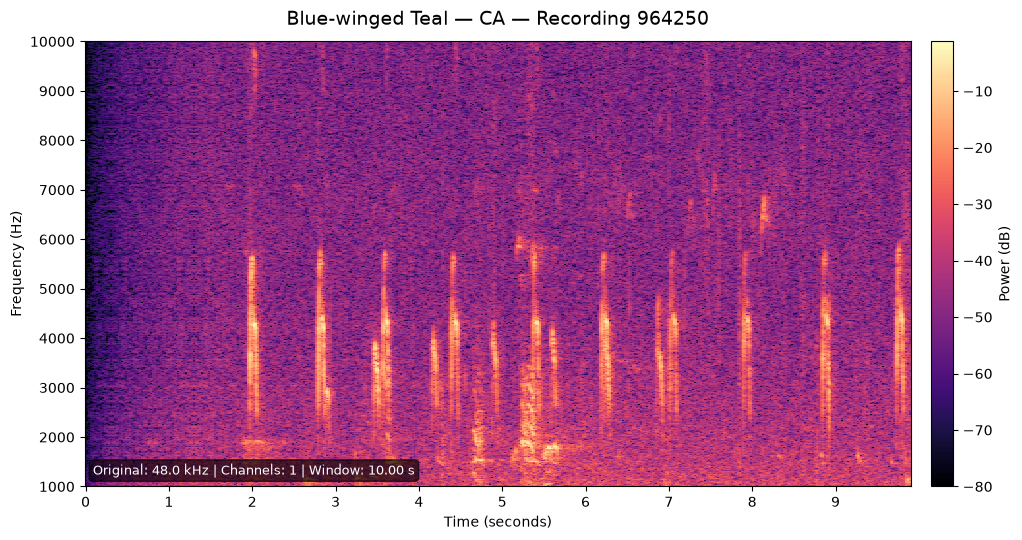

Saved: C:\Users\Samanwita\Downloads\from-soundscapes-to-biodiversity\figures\spectrograms\typical_clean_964250.png


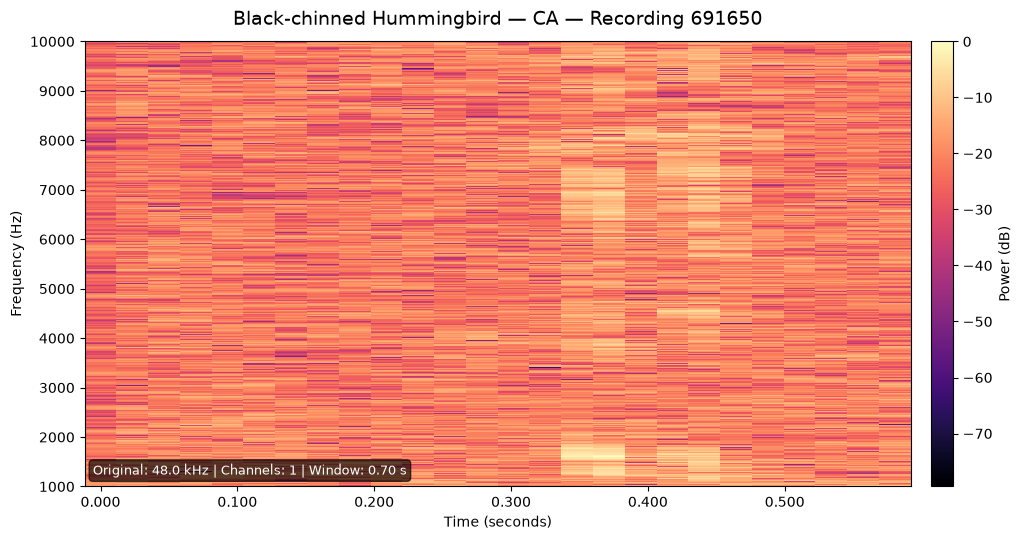

Saved: C:\Users\Samanwita\Downloads\from-soundscapes-to-biodiversity\figures\spectrograms\short_recording_691650.png


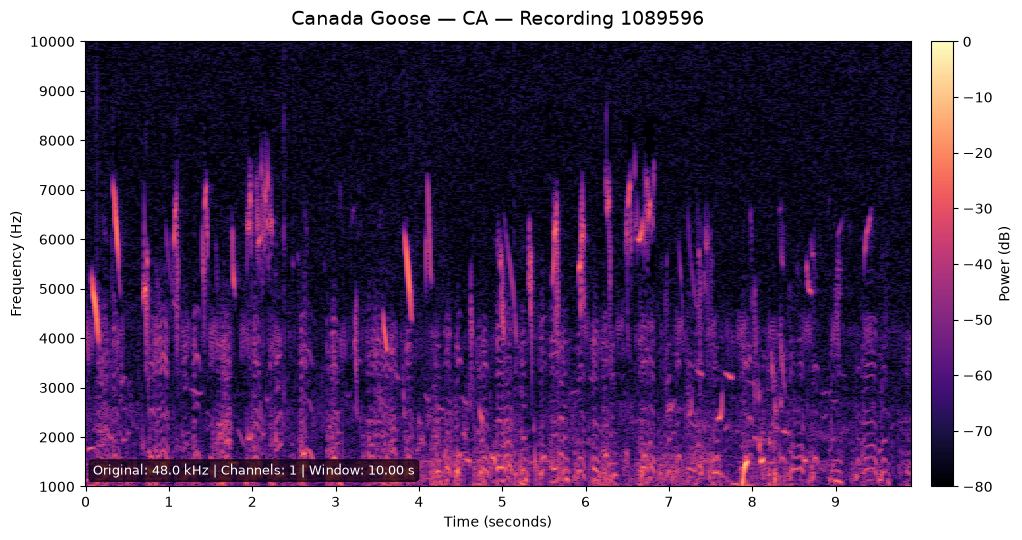

Saved: C:\Users\Samanwita\Downloads\from-soundscapes-to-biodiversity\figures\spectrograms\qc_flagged_1089596.png


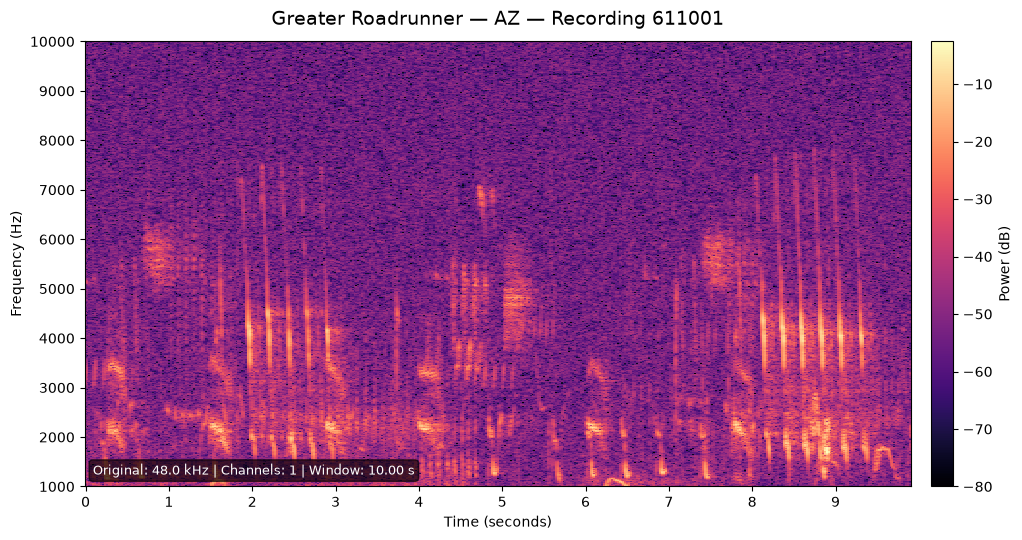

Saved: C:\Users\Samanwita\Downloads\from-soundscapes-to-biodiversity\figures\spectrograms\long_recording_611001.png


In [151]:
# ============================================================
# Generate Curated Spectrogram Gallery
# ============================================================

SPECTROGRAM_DIR.mkdir(parents=True, exist_ok=True)

for label, row in gallery_examples:

    recording_id = str(row["recording_id"])
    state = str(row["state"])

    audio_path = AUDIO_DIR / f"{state}_{recording_id}.mp3"

    # Load using the same standardization pipeline as feature extraction
    y, original_sr, original_channels = load_standardized_audio(
        audio_path,
        target_sr=FEATURE_CONFIG["analysis_sample_rate"]
    )

    # Use the first complete 10-second window when possible.
    # For recordings shorter than 10 seconds, use the entire recording.
    windows = create_analysis_windows(
        y,
        sample_rate=FEATURE_CONFIG["analysis_sample_rate"],
        window_seconds=FEATURE_CONFIG["window_seconds"]
    )

    first_window = windows[0]

    start = first_window["start_sample"]
    end = first_window["end_sample"]

    y_window = y[start:end]

    # Compute power spectrogram using the same configuration
    S_power, frequencies, times = compute_power_spectrogram(
        y_window,
        sample_rate=FEATURE_CONFIG["analysis_sample_rate"],
        n_fft=SPECTROGRAM_CONFIG["n_fft"],
        hop_length=SPECTROGRAM_CONFIG["hop_length"],
        window=SPECTROGRAM_CONFIG["window"],
        center=SPECTROGRAM_CONFIG["center"]
    )

    # Convert to decibels
    S_db = librosa.power_to_db(
        S_power,
        ref=np.max
    )

    # Restrict visualization to the primary 1–10 kHz band
    frequency_mask = (
        (frequencies >= FEATURE_CONFIG["primary_frequency_min_hz"]) &
        (frequencies <= FEATURE_CONFIG["primary_frequency_max_hz"])
    )

    S_db_primary = S_db[frequency_mask, :]
    frequencies_primary = frequencies[frequency_mask]

    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------

    fig, ax = plt.subplots(figsize=(11, 5.5))

    img = librosa.display.specshow(
        S_db_primary,
        sr=FEATURE_CONFIG["analysis_sample_rate"],
        hop_length=SPECTROGRAM_CONFIG["hop_length"],
        x_axis="time",
        y_axis="hz",
        ax=ax,
        cmap="magma"
    )

    ax.set_ylim(
        FEATURE_CONFIG["primary_frequency_min_hz"],
        FEATURE_CONFIG["primary_frequency_max_hz"]
    )

    ax.set_title(
        f"{row['common_name']} — {state} — "
        f"Recording {recording_id}",
        fontsize=14,
        pad=12
    )

    ax.set_xlabel("Time (seconds)")
    ax.set_ylabel("Frequency (Hz)")

    cbar = fig.colorbar(img, ax=ax, pad=0.02)
    cbar.set_label("Power (dB)")

    # Add a small metadata annotation
    metadata_text = (
        f"Original: {original_sr / 1000:.1f} kHz | "
        f"Channels: {original_channels} | "
        f"Window: {len(y_window) / FEATURE_CONFIG['analysis_sample_rate']:.2f} s"
    )

    ax.text(
        0.01,
        0.02,
        metadata_text,
        transform=ax.transAxes,
        fontsize=9,
        va="bottom",
        ha="left",
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="black",
            alpha=0.65
        ),
        color="white"
    )

    plt.tight_layout()

    output_path = SPECTROGRAM_DIR / f"{label}_{recording_id}.png"

    fig.savefig(
        output_path,
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)

    print("Saved:", output_path)

In [144]:
# ============================================================
# Save Spectrogram Gallery Metadata
# ============================================================

gallery_metadata = []

for label, row in gallery_examples:
    gallery_metadata.append({
        "gallery_label": label,
        "state": row["state"],
        "recording_id": str(row["recording_id"]),
        "common_name": row["common_name"],
        "scientific_name": row["scientific_name"],
        "duration_seconds": row["duration_seconds"],
        "flag_any": row["flag_any"],
        "flag_short_duration": row["flag_short_duration"],
        "spectrogram_frequency_range_hz": "1000-10000",
        "analysis_window_seconds": min(
            float(row["duration_seconds"]),
            FEATURE_CONFIG["window_seconds"]
        ),
        "image_file": f"{label}_{row['recording_id']}.png"
    })

gallery_metadata_df = pd.DataFrame(gallery_metadata)

GALLERY_METADATA_PATH = SPECTROGRAM_DIR / "gallery_metadata.csv"

gallery_metadata_df.to_csv(
    GALLERY_METADATA_PATH,
    index=False
)

print("Gallery metadata saved to:")
print(GALLERY_METADATA_PATH)

display(gallery_metadata_df)

Gallery metadata saved to:
C:\Users\Samanwita\Downloads\from-soundscapes-to-biodiversity\figures\spectrograms\gallery_metadata.csv


,gallery_label,state,recording_id,common_name,scientific_name,duration_seconds,flag_any,flag_short_duration,spectrogram_frequency_range_hz,analysis_window_seconds,image_file
0,typical_clean,CA,964250,Blue-winged Teal,Spatula discors,23.577188,False,False,1000-10000,10.000,typical_clean_964250.png
1,short_recording,CA,691650,Black-chinned Hummingbird,Archilochus alexandri,0.696000,True,True,1000-10000,0.696,short_recording_691650.png
2,qc_flagged,CA,1089596,Canada Goose,Branta canadensis,21.748833,True,False,1000-10000,10.000,qc_flagged_1089596.png
3,long_recording,AZ,611001,Greater Roadrunner,Geococcyx californianus,646.992000,False,False,1000-10000,10.000,long_recording_611001.png


In [146]:
# ============================================================
# Final Notebook 05 Quality Control
# ============================================================

print("=" * 60)
print("FINAL NOTEBOOK 05 QC")
print("=" * 60)

# ------------------------------------------------------------
# 1. Recording-level dataset
# ------------------------------------------------------------

print("\n[1] Recording-level dataset")

print(
    "Rows:",
    len(acoustic_features_recording_clean)
)

print(
    "Columns:",
    len(acoustic_features_recording_clean.columns)
)

print(
    "Total NaN values:",
    int(acoustic_features_recording_clean.isna().sum().sum())
)

# ------------------------------------------------------------
# 2. Recording uniqueness
# ------------------------------------------------------------

print("\n[2] Recording uniqueness")

print(
    "Unique recording IDs:",
    acoustic_features_recording_clean["recording_id"].nunique()
)

print(
    "Duplicate recording IDs:",
    int(
        acoustic_features_recording_clean["recording_id"]
        .duplicated()
        .sum()
    )
)

# ------------------------------------------------------------
# 3. Window-level dataset
# ------------------------------------------------------------

print("\n[3] Window-level dataset")

print(
    "Rows:",
    len(all_window_features)
)

print(
    "Unique recordings:",
    len(
        set(
            row["recording_id"]
            for row in all_window_features
        )
    )
)

# ------------------------------------------------------------
# 4. Extraction errors
# ------------------------------------------------------------

print("\n[4] Extraction errors")

print(
    "Extraction errors:",
    len(extraction_errors)
)

# ------------------------------------------------------------
# 5. Temporal entropy
# ------------------------------------------------------------

print("\n[5] Temporal entropy")

temporal_entropy_values = np.array([
    row["temporal_entropy"]
    for row in all_window_features
], dtype=float)

print(
    "Missing:",
    int(np.isnan(temporal_entropy_values).sum())
)

print(
    "Infinite:",
    int(np.isinf(temporal_entropy_values).sum())
)

# ------------------------------------------------------------
# 6. Short-window policy
# ------------------------------------------------------------

print("\n[6] Short-window policy")

short_window_values = pd.Series([
    row["flag_short_window"]
    for row in all_window_features
])

print(short_window_values.value_counts().sort_index())

# ------------------------------------------------------------
# 7. Feature manifest
# ------------------------------------------------------------

print("\n[7] Feature manifest")

print(
    "Rows:",
    len(feature_manifest_df)
)

print(
    "Columns:",
    len(feature_manifest_df.columns)
)

# ------------------------------------------------------------
# 8. Spectrogram gallery
# ------------------------------------------------------------

print("\n[8] Spectrogram gallery")

print(
    "Gallery examples:",
    len(gallery_metadata_df)
)

for image_file in gallery_metadata_df["image_file"]:

    image_path = SPECTROGRAM_DIR / image_file

    print(
        image_file,
        "->",
        "FOUND" if image_path.exists() else "MISSING"
    )

# ------------------------------------------------------------
# 9. Website export
# ------------------------------------------------------------

print("\n[9] Website export")

website_json_dir = (
    PROJECT_ROOT /
    "website" /
    "public" /
    "data"
)

if website_json_dir.exists():

    for json_file in [
        "recordings.json",
        "acoustic_features.json",
        "summary.json",
    ]:

        path = website_json_dir / json_file

        print(
            json_file,
            "->",
            "FOUND" if path.exists() else "MISSING"
        )

else:

    print("Website JSON directory not found.")

print("\n" + "=" * 60)
print("FINAL QC COMPLETE")
print("=" * 60)

FINAL NOTEBOOK 05 QC

[1] Recording-level dataset
Rows: 275
Columns: 115
Total NaN values: 0

[2] Recording uniqueness
Unique recording IDs: 275
Duplicate recording IDs: 0

[3] Window-level dataset
Rows: 1179
Unique recordings: 275

[4] Extraction errors
Extraction errors: 0

[5] Temporal entropy
Missing: 0
Infinite: 0

[6] Short-window policy
False    1126
True       53
Name: count, dtype: int64

[7] Feature manifest
Rows: 100
Columns: 5

[8] Spectrogram gallery
Gallery examples: 4
typical_clean_964250.png -> FOUND
short_recording_691650.png -> FOUND
qc_flagged_1089596.png -> FOUND
long_recording_611001.png -> FOUND

[9] Website export
recordings.json -> MISSING
acoustic_features.json -> FOUND
summary.json -> MISSING

FINAL QC COMPLETE


In [150]:
# Final compact QC

print("SHORT WINDOWS:")
print(
    acoustic_features_window["flag_short_window"]
    .value_counts()
    .sort_index()
)

print("\nFEATURE MANIFEST:")
print("Rows:", len(feature_manifest_df))
print("Columns:", len(feature_manifest_df.columns))

print("\nSPECTROGRAM GALLERY:")
print("Examples:", len(gallery_metadata_df))

for image_file in gallery_metadata_df["image_file"]:
    path = SPECTROGRAM_DIR / image_file
    print(
        image_file,
        "->",
        "FOUND" if path.exists() else "MISSING"
    )

print("\nWEBSITE JSON:")

website_json_dir = PROJECT_ROOT / "website" / "public" / "data"

for name in [
    "recordings.json",
    "acoustic_features.json",
    "summary.json"
]:
    path = website_json_dir / name
    print(
        name,
        "->",
        "FOUND" if path.exists() else "MISSING"
    )

SHORT WINDOWS:
flag_short_window
False    1126
True       53
Name: count, dtype: int64

FEATURE MANIFEST:
Rows: 100
Columns: 5

SPECTROGRAM GALLERY:
Examples: 4
typical_clean_964250.png -> FOUND
short_recording_691650.png -> FOUND
qc_flagged_1089596.png -> FOUND
long_recording_611001.png -> FOUND

WEBSITE JSON:
recordings.json -> FOUND
acoustic_features.json -> FOUND
summary.json -> FOUND


Notebook 05 — Audio Feature Extraction Summary

Audio from 275 selected Xeno-canto recordings was standardized to mono 22,050 Hz audio and segmented into complete 10-second analysis windows, with recordings shorter than 10 seconds analyzed using their full available duration without padding or looping. This produced 1,179 analysis windows.

Each window was characterized using ecological acoustic indices, spectral and temporal descriptors, and 13 MFCC coefficients. These measurements were aggregated to the recording level, producing 275 recording-level observations and 100 acoustic feature statistics.

Temporal entropy was calculated using float64 input to prevent numerical underflow identified during quality-control diagnostics of the scikit-maad entropy implementation. All temporal entropy values were finite after this correction.

Of the 275 recordings, 117 contained a single analysis window. Within-recording standard deviations are therefore undefined for these observations. These values were encoded as zero with an accompanying single_window indicator so that the distinction remains explicit and can be examined in downstream sensitivity analyses.

The resulting recording-level feature dataset and feature manifest were saved to the processed-data and manifest directories for downstream exploratory analysis, dimensionality reduction, clustering, and predictive modeling.